## Dags att labba med lite modellering och försöka hitta en skön funktion för att styra mitt "smarta hem".

In [ ]:
# Lite housekeeping - en del grejer är fragment från tidigare experiment, men de får stå kvar.

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from io import StringIO
from datetime import datetime, timedelta
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import optuna
from sklearn.model_selection import TimeSeriesSplit
optuna.logging.set_verbosity(optuna.logging.WARNING)
import calendar
import pulp

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Konstanter ──
LAT, LON      = 56.67, 12.86          # Halmstad
STATION_ID    = 62410                  # Halmstad Flygplats
MASTER_CSV    = "Datainsamling/Del 3 - Data för projektet/master_energy_data_cleaned.csv"
TRAIN_CUTOFF  = "2025-07-01"          # Allt före = träning
STRANG_PARAM  = 117                    # Global irradians W/m²


In [111]:
# Ladda in data från CSV-filen
df_master = pd.read_csv(MASTER_CSV, parse_dates=['timestamp'])
df_master = df_master.sort_values('timestamp').set_index('timestamp')

print(f"Rader:   {len(df_master):,}")
print(f"Kolumner: {df_master.columns.tolist()}")
print(f"Period:  {df_master.index.min()} → {df_master.index.max()}")
df_master.head(3)

Rader:   21,961
Kolumner: ['hour', 'weekday', 'is_weekend', 'month', 'season', 'hour_sin', 'hour_cos', 'temp_c', 'irradiance_wm2', 'grid_import_kwh', 'grid_export_kwh', 'total_production_kwh', 'self_consumption_kwh', 'total_house_load_kwh', 'net_balance_kwh', 'price_total_ore']
Period:  2023-07-01 00:00:00 → 2025-12-31 23:00:00


,hour,weekday,is_weekend,month,season,hour_sin,hour_cos,temp_c,irradiance_wm2,grid_import_kwh,grid_export_kwh,total_production_kwh,self_consumption_kwh,total_house_load_kwh,net_balance_kwh,price_total_ore
timestamp,,,,,,,,,,,,,,,,
2023-07-01 00:00:00,0,5,1,7,summer,0.000,1.000,14.239,0.000,0.800,0.000,0.000,0.000,0.800,-0.800,0.000
2023-07-01 01:00:00,1,5,1,7,summer,0.259,0.966,14.938,0.000,2.400,0.000,0.000,0.000,2.400,-2.400,34.859
2023-07-01 02:00:00,2,5,1,7,summer,0.500,0.866,16.050,0.000,6.000,0.000,0.000,0.000,6.000,-6.000,34.481


In [112]:
def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    """
    Jag hade inte koll på att även SMHI (via STRÅNG) har timvis data för solinstrålning 
    så jag kompletterar mina NASA-data med dessa.
    Returnerar en pd.Series med DateTime-index (Europe/Stockholm).
    Saknade värden (-999) ersätts med NaN.
    """
    from_str = date_from.strftime('%Y%m%d%H')   # format: YYYYMMDDHH
    to_str   = date_to.strftime('%Y%m%d%H')

    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print(f"Hämtar: {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    # Parsa ASCII: år mån dag timme värde
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(year=int(parts[0]), month=int(parts[1]),
                  day=int(parts[2]), hour=int(parts[3]),
                  tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                val = float(parts[4])
                rows.append((ts, val))
            except ValueError:
                continue

    s = pd.Series(
        {ts: v for ts, v in rows},
        name='strang_ghi_wm2'
    )
    s = s.replace(-999, np.nan)   # Saknade värden → NaN
    print(f"STRÅNG: {len(s):,} timmar | "
          f"Saknade: {s.isna().sum()} | "
          f"Max: {s.max():.0f} W/m²")
    return s

# Hämta hela perioden
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)
strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)
strang_series.head()


Hämtar: https://opendata-download-metanalys.smhi.se/api/category/strang1g/version/1/geotype/point/lon/12.86/lat/56.67/parameter/117/data.txt?from=2023070100&to=2025123123&interval=hourly
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²


2023-07-01 02:00:00    0.000
2023-07-01 03:00:00    0.000
2023-07-01 04:00:00    0.000
2023-07-01 05:00:00    8.200
2023-07-01 06:00:00   54.300
Name: strang_ghi_wm2, dtype: float64

In [113]:
def fetch_metobs_temperature(station_id):
    """
    Hämtar timvis lufttemperatur (parameter 1) från SMHI metobs.
    Kombinerar corrected-archive + latest-months automatiskt.
    Returnerar en pd.Series med DateTime-index (UTC→Europe/Stockholm).
    """
    base = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            # SMHI CSV har metadata-rader i toppen — hoppa över dem
            lines = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,           # SMHI kör UTC av någon anledning
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)  # → lokal tid
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'
    print(f"\nmetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()}")
    return df_obs

temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()


  Period 'corrected-archive': 255944 rader
  Period 'latest-months': 3128 rader

metobs temp: 258,438 timmar | Period: 1945-02-06 → 2026-04-15


timestamp
1945-02-06 08:00:00   0.400
1945-02-06 14:00:00   1.000
1945-02-07 08:00:00   1.200
1945-02-07 14:00:00   1.800
1945-02-08 08:00:00   1.800
Name: temp_obs_c, dtype: float64

In [114]:
# Slå ihop alla datakällor
df = df_master.copy()
df['strang_ghi']  = strang_series
df['temp_obs']    = temp_obs

# Interpolera korta luckor i STRÅNG (max 2h)
df['strang_ghi'] = df['strang_ghi'].interpolate(method='time', limit=2)

# ── Kalenderfeatures ──
df['hour']       = df.index.hour
df['month']      = df.index.month
df['weekday']    = df.index.dayofweek
df['day_of_year']= df.index.dayofyear

# ── Solhöjdsapproximation (enkel, utan ephem) ──
# Solhorisontell strålning minskar mot morgon/kväll → modelleras med sin-kurva
df['solar_angle'] = np.sin(
    np.pi * (df['hour'] - 6) / 14          # 0 vid 6:00, max vid 13:00, 0 vid 20:00
).clip(lower=0)

# ── Daglig aggregat-features (för prognos dagen efter) ──
daily = df.resample('D').agg(
    production     = ('total_production_kwh', 'sum'),
    strang_mean    = ('strang_ghi', 'mean'),
    strang_max     = ('strang_ghi', 'max'),
    temp_max       = ('temp_obs', 'max'),
    temp_mean      = ('temp_obs', 'mean'),
    house_load_sum = ('total_house_load_kwh', 'sum'),
    month          = ('month', 'first'),
    weekday        = ('weekday', 'first'),
    day_of_year    = ('day_of_year', 'first'),
).dropna(subset=['production', 'strang_mean'])

# ── Laggade features (ingen data leakage!) ──
for lag in [1, 2, 7]:
    daily[f'prod_lag{lag}']   = daily['production'].shift(lag)
    daily[f'strang_lag{lag}'] = daily['strang_mean'].shift(lag)

daily['prod_roll7']   = daily['production'].shift(1).rolling(7).mean()
daily['prod_roll14']  = daily['production'].shift(1).rolling(14).mean()
daily['strang_roll7'] = daily['strang_mean'].shift(1).rolling(7).mean()

# ── Årstidscykel ──
daily['season_sin'] = np.sin(2 * np.pi * daily['day_of_year'] / 365.25)
daily['season_cos'] = np.cos(2 * np.pi * daily['day_of_year'] / 365.25)

# Target = nästa dags produktion
daily['target'] = daily['production'].shift(-1)
daily = daily.dropna()

print(f"Dataunderlag klart: {len(daily)} dagar")
print(f"Träning (< {TRAIN_CUTOFF}): {(daily.index < TRAIN_CUTOFF).sum()} dagar")
print(f"Test   (≥ {TRAIN_CUTOFF}): {(daily.index >= TRAIN_CUTOFF).sum()} dagar")
daily.head(3)


Dataunderlag klart: 892 dagar
Träning (< 2025-07-01): 710 dagar
Test   (≥ 2025-07-01): 182 dagar


,production,strang_mean,strang_max,temp_max,temp_mean,house_load_sum,month,weekday,day_of_year,prod_lag1,...,prod_lag2,strang_lag2,prod_lag7,strang_lag7,prod_roll7,prod_roll14,strang_roll7,season_sin,season_cos,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-15,24.525,205.487,674.700,26.100,19.754,47.425,7,5,196,53.221,...,52.053,304.775,56.102,331.250,40.874,36.632,260.129,-0.228,-0.974,40.077
2023-07-16,40.077,250.362,791.600,21.800,18.954,51.577,7,6,197,24.525,...,53.221,314.988,55.834,326.050,36.363,37.906,242.163,-0.245,-0.970,45.520
2023-07-17,45.520,245.112,767.800,19.400,17.062,39.520,7,0,198,40.077,...,24.525,205.487,13.103,150.908,34.112,37.389,231.351,-0.261,-0.965,37.902


In [115]:
FEATURES = [
    'strang_lag1', 'strang_lag2', 'strang_lag7', 'strang_roll7',
    'strang_max',
    'temp_max', 'temp_mean',
    'prod_lag1', 'prod_lag2', 'prod_lag7',
    'prod_roll7', 'prod_roll14',
    'month', 'weekday', 'season_sin', 'season_cos',
]

mask_train = daily.index < TRAIN_CUTOFF
mask_test  = daily.index >= TRAIN_CUTOFF

X_train = daily.loc[mask_train, FEATURES]
y_train = daily.loc[mask_train, 'target']
X_test  = daily.loc[mask_test,  FEATURES]
y_test  = daily.loc[mask_test,  'target']

model = HistGradientBoostingRegressor(
    max_iter             = 1000,
    learning_rate        = 0.02,
    max_depth            = 4,
    min_samples_leaf     = 5,
    l2_regularization    = 0.5,
    random_state         = 42,
    early_stopping       = True,
    validation_fraction  = 0.15,
    n_iter_no_change     = 50,
)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

def metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10}  MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsdagar: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()
res_train = metrics(y_train, y_pred_train, "TRÄNING")
res_test  = metrics(y_test,  y_pred_test,  "TEST")

Antal träningsdagar: 710
Tidiga stopp vid iteration: 186

TRÄNING     MAE=7.61 kWh  RMSE=9.53 kWh  R²=0.7390
TEST        MAE=8.92 kWh  RMSE=11.01 kWh  R²=0.6162


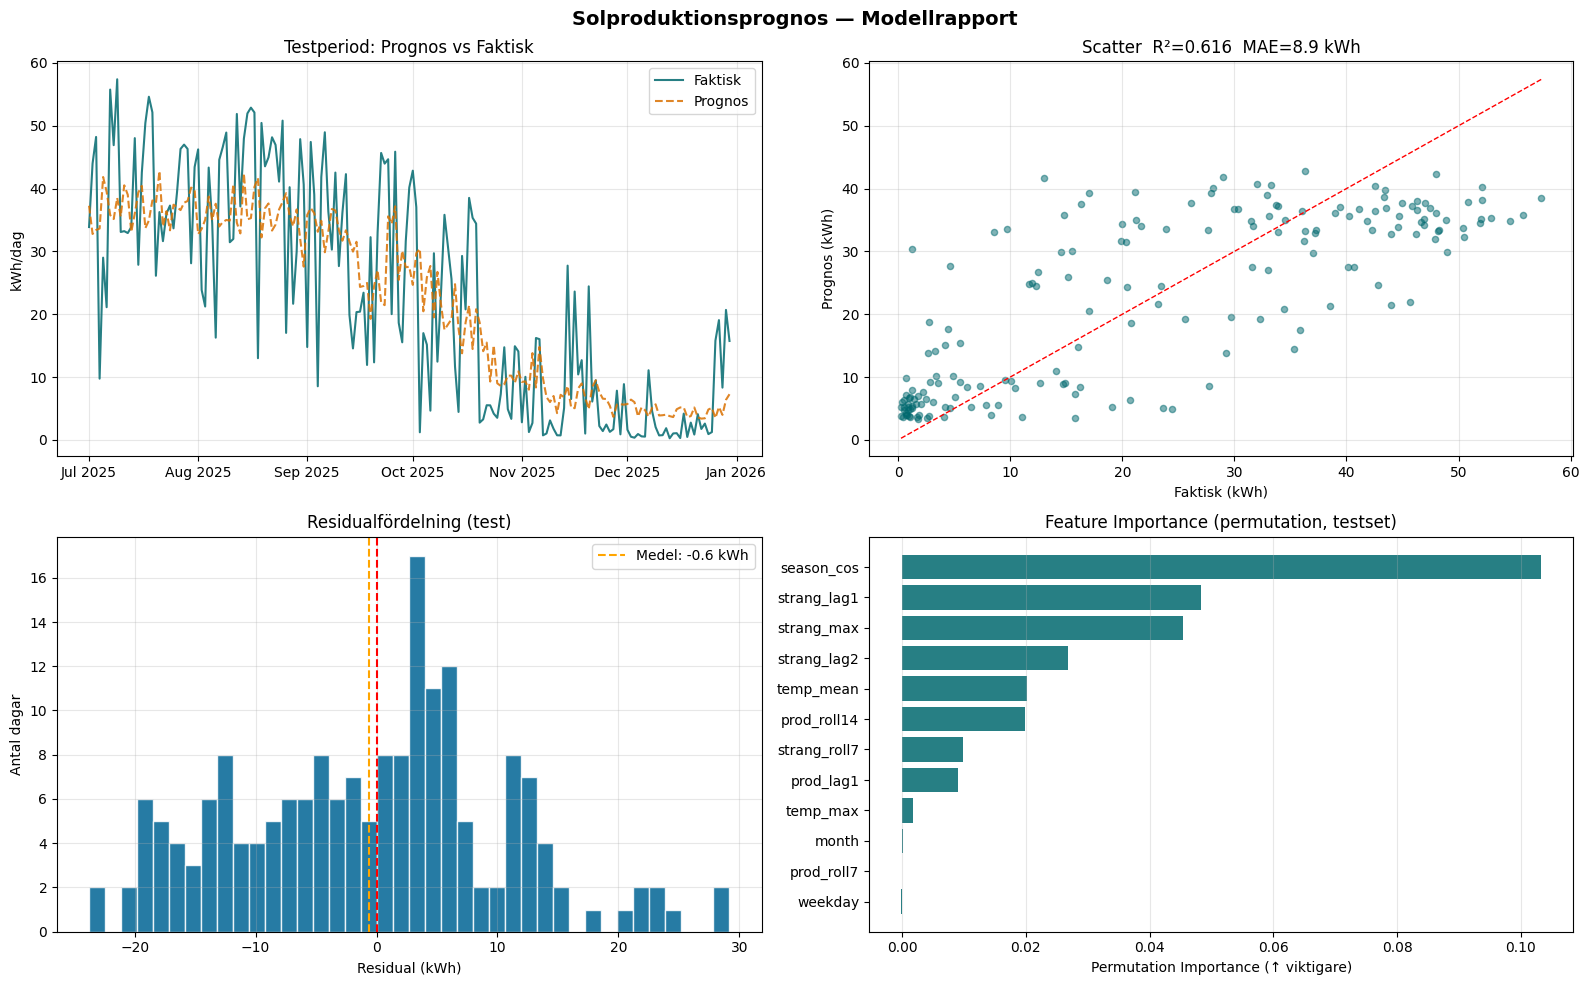

Rapport sparad: model_report.png


In [116]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport', fontsize=14, fontweight='bold')

# ── Panel 1: Prognos vs faktisk (testperiod) ──
ax = axes[0, 0]
ax.plot(daily.loc[mask_test].index, y_test.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(daily.loc[mask_test].index, y_pred_test,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Scatter prognos vs faktisk ──
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test, alpha=0.5, color='#01696f', s=20)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)'); ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.1f} kWh")
ax.grid(alpha=0.3)

# ── Panel 3: Residualfördelning ──
ax = axes[1, 0]
residuals = y_pred_test - y_test.values
ax.hist(residuals, bins=40, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.1f} kWh')
ax.set_xlabel('Residual (kWh)'); ax.set_ylabel('Antal dagar')
ax.set_title('Residualfördelning (test)')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 4: Feature importance ──
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)
bars = ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")


## Sammanfattning av features för modellen

| Feature      | Vad den mäter                                                                                                                   |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------- |
| season_cos   | Cosinustransformation av årets dag — berättar var i årscykeln vi är på ett cirkulärt korrekt sätt. Högst vikt av alla features. |
| season_sin   | Sinustransformation av samma sak — kompletterar season_cos för att fånga asymmetrin mellan vår och höst.                        |
| strang_lag1  | STRÅNG-strålningen igår i W/m² — proxy för om vädret var soligt senaste dygnet.                                                 |
| strang_lag2  | STRÅNG-strålningen i förrgår — fångar upp om ett väderläge håller i sig över flera dagar.                                       |
| strang_lag7  | Strålningen för exakt en vecka sedan — fångar veckosäsonsmönster och återkommande väderlägen.                                   |
| strang_max   | Högsta timvärdet för strålning under dagen — mäter om det någon gång under dagen var klart, även om medlet var lågt.            |
| strang_roll7 | Rullande 7-dagarmedel av strålning — jämnar ut brus och ger en stabil bild av det senaste väderläget.                           |
| temp_max     | Högsta temperaturen under dagen — korrelerat med soliga dagar eftersom kraftig sol värmer upp mer.                              |
| temp_mean    | Medeltemperaturen under dagen — komplement till temp_max, speglar även årstid och molnighet indirekt.                           |
| prod_lag1    | Faktisk solproduktion igår i kWh — direkt signal om hur panelerna presterade senast.                                            |
| prod_lag2    | Faktisk solproduktion i förrgår — fångar om ett bra eller dåligt väderläge håller i sig.                                        |
| prod_lag7    | Produktionen för exakt en vecka sedan — samma logik som strang_lag7 men baserat på faktiskt utfall.                             |
| prod_roll7   | Rullande 7-dagarmedel av produktion — stabiliserar mot kortsiktigt brus, liknar strang_roll7.                                   |
| prod_roll14  | Rullande 14-dagarmedel — längre horisont än roll7, fångar övergångar mellan säsonger bättre.                                    |
| month        | Kalendermånad (1–12) — delvis redundant med season_cos/sin men kan fånga månadsspecifika mönster.                               |
| weekday      | Veckodag (0–6) — solen bryr sig inte om veckodagen, därav nära noll i importance.                                               |
| is_weekend   | Helgflagga — liknande resonemang som weekday, minimal påverkan på solproduktion.                                                |

Några kommentarer:

1. I diagrammet Prognos vs Faktisk (övre vänster) ser vi hur prognosen inte är så dålig på att pricka trenden, men missar topparna och dalarna som är så viktiga för den här funktionen. Detta beror på att modellen saknar framåtblickande väderfeatures. Det är så det blir i en trädbaserad modell utan väderprognosinput. Detta får vi titta på i nästa steg.

2. Scatterdiagrammet har två tydliga mönster - på samma tema. Den underskattar höga värden och chansar aldrig på de riktigt soliga dagarna. 

3. Residualfördelningen (nedre vänster) visar att modellen är svagt pessimistisk och det får jag aceptera. Residualer upp mot +30 kWh är missade soliga sommardagar som modellen underskattar.

4. Listan på features som är viktiga för modellen visar föga överraskande att season_cos är viktigast medan veckodag är minst viktigt. 

Jag gjorde lite research och det visar sig att jag slarvat när jag hämtat NASA-data. Jag behöver komplettera med ALLSKY_KT (klarhetsindex).  låter delarna ovan stå kvar för att visa hur arbetsgången varit. 


In [117]:
# SMHI STRÅNG + läs NASA ALLSKY_KT från fil

# Hårdkodad period
date_from = datetime(2023, 7, 1, 0)
date_to   = datetime(2025, 12, 31, 23)

KT_CSV = r"Datainsamling/Del 3 - Data för projektet/nasa_allsky_kt.csv"

# ── Del A: STRÅNG ──────────────────────────────────────────────────────────

def fetch_strang_hourly(lat, lon, param, date_from, date_to):
    from_str = date_from.strftime('%Y%m%d%H')
    to_str   = date_to.strftime('%Y%m%d%H')
    url = (
        f"https://opendata-download-metanalys.smhi.se/api/category/strang1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}"
        f"/parameter/{param}/data.txt"
        f"?from={from_str}&to={to_str}&interval=hourly"
    )
    print("Hämtar STRÅNG...")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    rows = []
    for line in r.text.strip().splitlines():
        parts = line.split()
        if len(parts) == 5:
            try:
                ts = pd.Timestamp(
                    year=int(parts[0]), month=int(parts[1]),
                    day=int(parts[2]),  hour=int(parts[3]),
                    tz='UTC'
                ).tz_convert('Europe/Stockholm').tz_localize(None)
                rows.append((ts, float(parts[4])))
            except ValueError:
                continue
    s = pd.Series({ts: v for ts, v in rows}, name='strang_ghi_wm2')
    s = s.replace(-999, np.nan)
    print(f"STRÅNG: {len(s):,} timmar | Saknade: {s.isna().sum()} | Max: {s.max():.0f} W/m²")
    return s

strang_series = fetch_strang_hourly(LAT, LON, STRANG_PARAM, date_from, date_to)

# ── Del B: NASA ALLSKY_KT från fil ────────────────────────────────────────

kt_series = pd.read_csv(
    KT_CSV,
    index_col='timestamp',
    parse_dates=['timestamp']
)['allsky_kt']

kt_series = kt_series.groupby(kt_series.index).mean()

df_master['allsky_kt'] = df_master.index.astype('datetime64[ns]').map(kt_series)

print(f"ALLSKY_KT: {len(kt_series):,} timmar | Period: {kt_series.index.min().date()} → {kt_series.index.max().date()}")
print(f"Matchade rader:  {df_master['allsky_kt'].notna().sum():,} av {len(df_master):,}")
print(f"Saknade:         {df_master['allsky_kt'].isna().sum()}")

Hämtar STRÅNG...
STRÅNG: 21,957 timmar | Saknade: 192 | Max: 871 W/m²
ALLSKY_KT: 21,960 timmar | Period: 2023-07-01 → 2025-12-31
Matchade rader:  11,115 av 21,961
Saknade:         10846


In [118]:
# SMHI metobs: timvis lufttemperatur för flygplatsen som bara är några km bort

METOBS_CSV = r"Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv"

def fetch_metobs_temperature(station_id):
    base   = "https://opendata-download-metobs.smhi.se/api/version/1.0"
    frames = []

    for period in ['corrected-archive', 'latest-months']:
        url = f"{base}/parameter/1/station/{station_id}/period/{period}/data.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            lines      = r.content.decode('utf-8-sig').splitlines()
            data_start = next(
                i for i, l in enumerate(lines)
                if l.startswith('Datum') or l.startswith('datum')
            )
            csv_text = '\n'.join(lines[data_start:])
            tmp = pd.read_csv(
                StringIO(csv_text),
                sep=';',
                usecols=[0, 1, 2],
                names=['datum', 'tid_utc', 'temp_obs'],
                skiprows=1,
                dtype={'temp_obs': str}
            )
            tmp['timestamp'] = pd.to_datetime(
                tmp['datum'] + ' ' + tmp['tid_utc'],
                utc=True,
                errors='coerce'
            ).dt.tz_convert('Europe/Stockholm').dt.tz_localize(None)
            tmp['temp_obs'] = pd.to_numeric(tmp['temp_obs'], errors='coerce')
            frames.append(tmp[['timestamp', 'temp_obs']].dropna())
            print(f"  Period '{period}': {len(tmp)} rader")
        except Exception as e:
            print(f"  Period '{period}': hoppades över ({e})")

    df_obs = pd.concat(frames).drop_duplicates('timestamp')
    df_obs = df_obs.set_index('timestamp').sort_index()['temp_obs']
    df_obs.name = 'temp_obs_c'

    # Spara som CSV
    df_obs.to_csv(METOBS_CSV, index=True, index_label='timestamp')

    print(f"\nMetobs temp: {len(df_obs):,} timmar | "
          f"Period: {df_obs.index.min().date()} → {df_obs.index.max().date()} | "
          f"Sparad: {METOBS_CSV}")
    return df_obs


temp_obs = fetch_metobs_temperature(STATION_ID)
temp_obs.head()

  Period 'corrected-archive': 255944 rader
  Period 'latest-months': 3128 rader

Metobs temp: 258,438 timmar | Period: 1945-02-06 → 2026-04-15 | Sparad: Datainsamling/Del 3 - Data för projektet/smhi_metobs.csv


timestamp
1945-02-06 08:00:00   0.400
1945-02-06 14:00:00   1.000
1945-02-07 08:00:00   1.200
1945-02-07 14:00:00   1.800
1945-02-08 08:00:00   1.800
Name: temp_obs_c, dtype: float64

In [119]:
# Slå ihop datakällor och bygg timvisa features

df = df_master.copy()
df = df.rename(columns={
    'total_production_kwh': 'totalproductionkwh',
    'allsky_kt':            'allskykt',
})

# Interpolera korta luckor i STRÅNG max 2h
df['strangghiwm2'] = strang_series   # ← lägg till denna rad
df['strangghiwm2'] = df['strangghiwm2'].interpolate(method='time', limit=2)

# Lägg till temp_obs
df['tempobs'] = temp_obs   

# Kalenderfeatures
df['hour'] = df.index.hour
df['month'] = df.index.month
df['weekday'] = df.index.dayofweek
df['dayofyear'] = df.index.dayofyear

# Solhöjdsapproximation
df['solarangle'] = np.clip(np.sin(np.pi * (df['hour'] - 6) / 14), 0, None)

# Timvisa lag-features
for lag_h in [24, 48, 168]:
    df[f'prod_lag{lag_h}h'] = df['totalproductionkwh'].shift(lag_h)
    df[f'strang_lag{lag_h}h'] = df['strangghiwm2'].shift(lag_h)
    df[f'kt_lag{lag_h}h'] = df['allskykt'].shift(lag_h)

# Rullande historik på timnivå
df['prod_roll7d'] = df['totalproductionkwh'].shift(24).rolling(7 * 24, min_periods=24).mean()
df['prod_roll14d'] = df['totalproductionkwh'].shift(24).rolling(14 * 24, min_periods=24).mean()
df['strang_roll7d'] = df['strangghiwm2'].shift(24).rolling(7 * 24, min_periods=24).mean()

# Årstidscykel
df['season_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
df['season_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

# Timvis target
df['target_log'] = np.log1p(df['totalproductionkwh'])

# Träna bara på timmar där solen faktiskt kan bidra
dfh = df[df['solarangle'] > 0].copy()

required_cols = [
    'solarangle',
    'strangghiwm2',
    'allskykt',
    'tempobs',
    'hour',
    'month',
    'season_sin',
    'season_cos',
    'prod_lag24h',
    'prod_lag48h',
    'prod_lag168h',
    'strang_lag24h',
    'strang_lag48h',
    'strang_lag168h',
    'kt_lag24h',
    'kt_lag48h',
    'kt_lag168h',
    'prod_roll7d',
    'prod_roll14d',
    'strang_roll7d',
    'target_log',
]

dfh = dfh.dropna(subset=required_cols)

# Behåll daily för enkel dagssummering och utskrift
daily = df.resample('D').agg(
    production=('totalproductionkwh', 'sum'),
    strang_mean=('strangghiwm2', 'mean'),
    kt_mean=('allskykt', 'mean'),
).dropna()

print(f"Timvis dataset klart: {len(dfh)} rader")
print(f"Period: {dfh.index.min()} → {dfh.index.max()}")
print(f"Träning: {(dfh.index < pd.Timestamp(TRAIN_CUTOFF)).sum()} timmar")
print(f"Test:    {(dfh.index >= pd.Timestamp(TRAIN_CUTOFF)).sum()} timmar")

dfh.head(3)

Timvis dataset klart: 9206 rader
Period: 2023-07-08 07:00:00 → 2025-12-30 14:00:00
Träning: 7362 timmar
Test:    1844 timmar


,hour,weekday,is_weekend,month,season,hour_sin,hour_cos,temp_c,irradiance_wm2,grid_import_kwh,...,kt_lag48h,prod_lag168h,strang_lag168h,kt_lag168h,prod_roll7d,prod_roll14d,strang_roll7d,season_sin,season_cos,target_log
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-07-08 07:00:00,7,5,1,7,summer,0.966,-0.259,24.500,286.520,0.100,...,0.210,0.253,90.200,0.270,1.172,1.172,194.749,-0.109,-0.994,0.730
2023-07-08 08:00:00,8,5,1,7,summer,0.866,-0.500,25.950,428.580,0.000,...,0.180,0.752,133.200,0.260,1.181,1.181,195.822,-0.109,-0.994,1.345
2023-07-08 09:00:00,9,5,1,7,summer,0.707,-0.707,27.062,566.450,0.000,...,0.170,0.656,202.800,0.280,1.203,1.203,195.684,-0.109,-0.994,1.715


In [120]:
# Träna timvis modell

FEATURES = [
    'solarangle',
    'strangghiwm2',
    'allskykt',
    'tempobs',
    'hour',
    'month',
    'season_sin',
    'season_cos',
    'prod_lag24h',
    'prod_lag48h',
    'prod_lag168h',
    'strang_lag24h',
    'strang_lag48h',
    'strang_lag168h',
    'kt_lag24h',
    'kt_lag48h',
    'kt_lag168h',
    'prod_roll7d',
    'prod_roll14d',
    'strang_roll7d',
]

mask_train = dfh.index < pd.Timestamp(TRAIN_CUTOFF)
mask_test = dfh.index >= pd.Timestamp(TRAIN_CUTOFF)

X_train = dfh.loc[mask_train, FEATURES]
y_train = dfh.loc[mask_train, 'target_log']

X_test = dfh.loc[mask_test, FEATURES]
y_test = dfh.loc[mask_test, 'target_log']

model = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.02,
    max_depth=5,
    min_samples_leaf=10,
    l2_regularization=0.3,
    loss='squared_error',
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42,
)

model.fit(X_train, y_train)
y_pred_test = np.clip(np.expm1(model.predict(X_test)), 0, None)
y_pred_train = np.clip(np.expm1(model.predict(X_train)), 0, None)

def metrics(ytrue_log, ypred_log, label):
    ytrue = np.expm1(ytrue_log)
    ypred = np.clip(np.expm1(ypred_log), 0, None)
    mae = mean_absolute_error(ytrue, ypred)
    rmse = np.sqrt(mean_squared_error(ytrue, ypred))
    r2 = r2_score(ytrue, ypred)
    print(f"{label:<10} MAE={mae:.2f} kWh  RMSE={rmse:.2f} kWh  R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

print(f"Antal träningsrader: {len(X_train)}")
print(f"Tidiga stopp vid iteration: {model.n_iter_}")
print()

res_train = metrics(y_train, model.predict(X_train), "TRÄNING")
res_test = metrics(y_test, model.predict(X_test), "TEST")

Antal träningsrader: 7362
Tidiga stopp vid iteration: 1000

TRÄNING    MAE=0.35 kWh  RMSE=0.57 kWh  R²=0.9373
TEST       MAE=0.49 kWh  RMSE=0.80 kWh  R²=0.8662


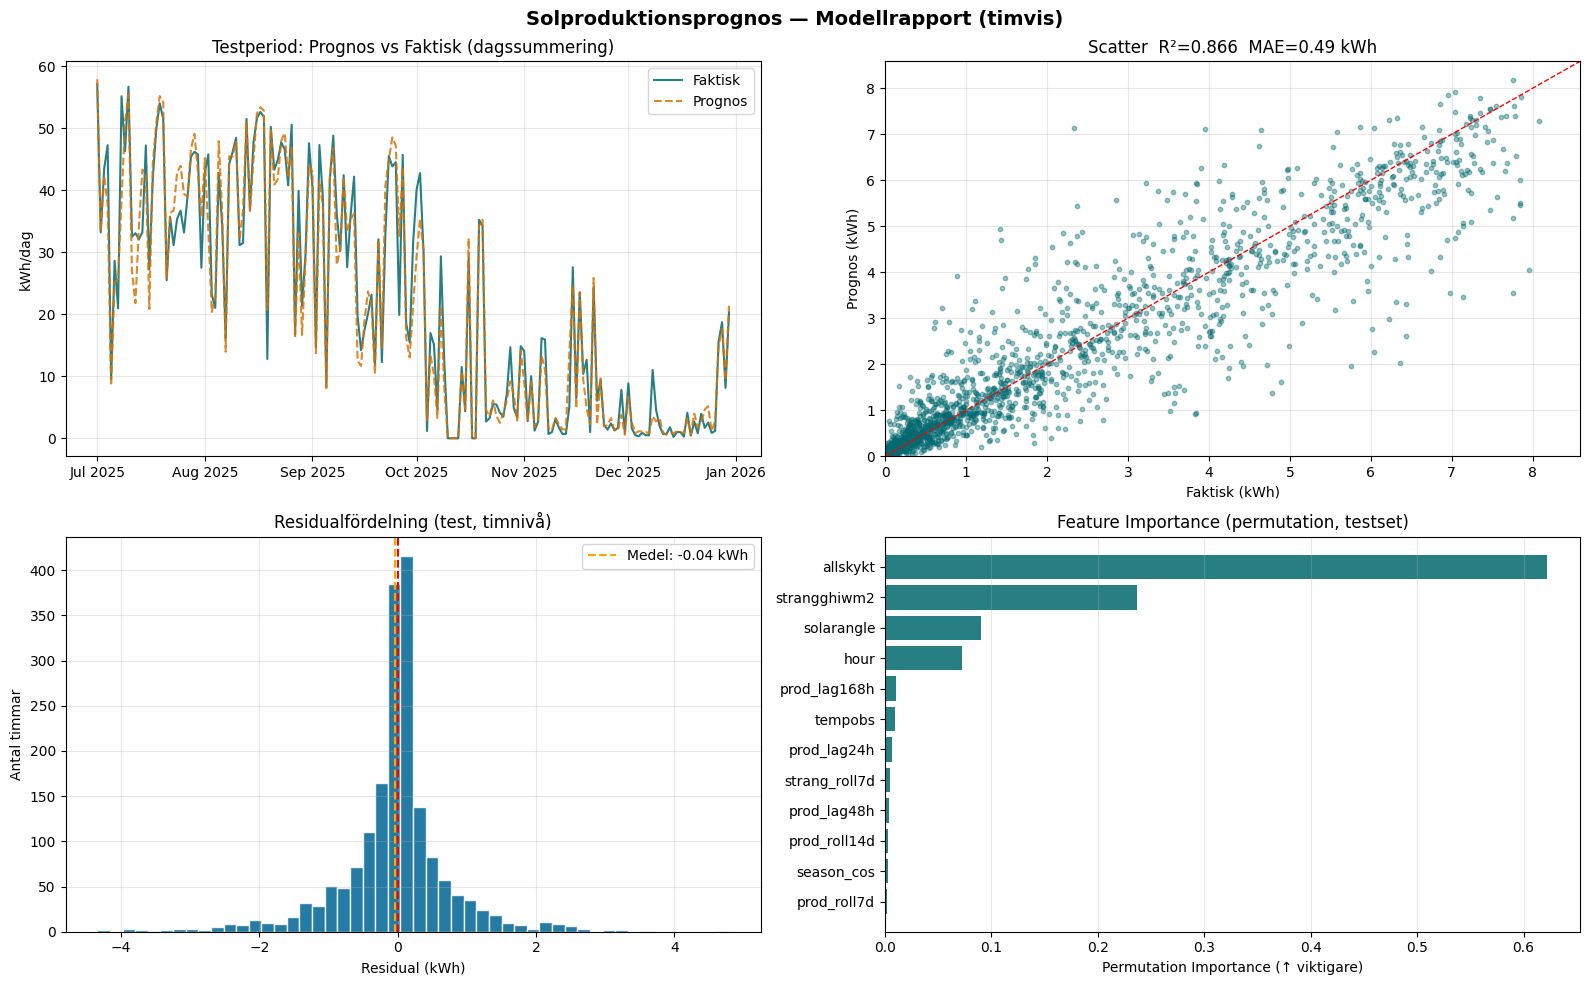

Rapport sparad: model_report.png


In [121]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Solproduktionsprognos — Modellrapport (timvis)', fontsize=14, fontweight='bold')

# Konvertera y_test från log-rymd → kWh
y_test_kwh  = np.expm1(y_test)                                              # Series med korrekt index
y_pred_test = np.clip(np.expm1(model.predict(X_test)), 0, None)             # ndarray i kWh
y_pred_series = pd.Series(y_pred_test, index=X_test.index, name='predicted_kwh')

# Summera timvisa värden till dag för en läsbar linjegraf
actual_daily  = y_test_kwh.resample('D').sum()
pred_daily    = y_pred_series.resample('D').sum()

# ── Panel 1: Prognos vs faktisk (testperiod, daglig summering) ──
ax = axes[0, 0]
ax.plot(actual_daily.index, actual_daily.values,
        label='Faktisk', color='#01696f', linewidth=1.5, alpha=0.85)
ax.plot(pred_daily.index, pred_daily.values,
        label='Prognos', color='#da7101', linewidth=1.5, alpha=0.85, linestyle='--')
ax.set_title('Testperiod: Prognos vs Faktisk (dagssummering)')
ax.set_ylabel('kWh/dag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 2: Scatter prognos vs faktisk (timnivå) ──
ax = axes[0, 1]
ax.scatter(y_test_kwh.values, y_pred_test, alpha=0.4, color='#01696f', s=10)
lims = [0, max(y_test_kwh.max(), y_pred_test.max()) * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Faktisk (kWh)')
ax.set_ylabel('Prognos (kWh)')
ax.set_title(f"Scatter  R²={res_test['r2']:.3f}  MAE={res_test['mae']:.2f} kWh")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.grid(alpha=0.3)

# ── Panel 3: Residualfördelning (kWh) ──
ax = axes[1, 0]
residuals = y_pred_test - y_test_kwh.values
ax.hist(residuals, bins=50, color='#006494', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--')
ax.axvline(residuals.mean(), color='orange', linestyle='--',
           label=f'Medel: {residuals.mean():.2f} kWh')
ax.set_xlabel('Residual (kWh)')
ax.set_ylabel('Antal timmar')
ax.set_title('Residualfördelning (test, timnivå)')
ax.legend()
ax.grid(alpha=0.3)

# ── Panel 4: Feature importance (log-rymd, korrekt för modellen) ──
ax = axes[1, 1]
imp_result = permutation_importance(model, X_test, y_test,   # ← log-rymd är rätt här
                                    n_repeats=10, random_state=42)
imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': imp_result.importances_mean
}).sort_values('importance', ascending=True).tail(12)

ax.barh(imp_df['feature'], imp_df['importance'], color='#01696f', alpha=0.85)
ax.set_xlabel('Permutation Importance (↑ viktigare)')
ax.set_title('Feature Importance (permutation, testset)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rapport sparad: model_report.png")

Äntligen en bra modell - nu kör vi nästa steg. 

In [166]:
def fetch_smhi_forecast(lat, lon):
    """
    Hämtar SMHI:s 10-dygns timprognos via snow1g/version/1 (ersätter pmp3g 2026-03-31).
    data-fältet är ett dict: {"air_temperature": 12.3, "tcc_mean": 6, ...}
    Det handlar inte om snö utan är SNOW (Swedish National Operational Weather forecast),
    en sammanställning av prognoser som uppdateras var 15:e minut.
    """
    url = (
        f"https://opendata-download-metfcst.smhi.se/api/category/snow1g"
        f"/version/1/geotype/point/lon/{lon}/lat/{lat}/data.json"
    )
    r = requests.get(url, timeout=15)
    r.raise_for_status()

    rows = []
    for step in r.json()['timeSeries']:
        ts = (pd.Timestamp(step['time'])          # ← 'time' är korrekt
              .tz_convert('Europe/Stockholm')
              .tz_localize(None))
        d = step['data']   # ← dict direkt, stämmer
        rows.append({
            'timestamp':         ts,
            'temp_c':            d.get('air_temperature'),
            'humidity_pct':      d.get('relative_humidity'),
            'cloud_total_octas': d.get('cloud_area_fraction'),          # ← nytt namn
            'cloud_low_octas':   d.get('low_type_cloud_area_fraction'), # ← nytt namn
            'weather_symbol':    d.get('symbol_code'),                  # ← nytt namn
        })

    fcst = pd.DataFrame(rows).set_index('timestamp')
    fcst['cloud_total_pct'] = fcst['cloud_total_octas'] * (100 / 8)
    fcst['cloud_low_pct']   = fcst['cloud_low_octas']   * (100 / 8)

    print(f"snow1g: {len(fcst)} timmar | "
          f"{fcst.index.min().date()} → {fcst.index.max().date()}")
    return fcst

def lookup_or_fallback(frame, col, ts, fallback):
    try:
        val = frame.loc[ts, col]
        return fallback if pd.isna(val) else val
    except KeyError:
        return fallback


def build_tomorrow_hourly_features(df_hist, fcst_df):
    tomorrow  = (pd.Timestamp.now() + pd.Timedelta(days=1)).date()
    tmrw_fcst = fcst_df[fcst_df.index.date == tomorrow].copy()

    if tmrw_fcst.empty:
        available = sorted(set(fcst_df.index.date))
        raise ValueError(f"Ingen prognos för {tomorrow}.\nTillgängliga datum: {available}")

    hour_arr    = tmrw_fcst.index.hour.to_numpy()
    solar_angle = np.clip(np.sin(np.pi * (hour_arr - 6) / 14), 0, None)
    month          = tomorrow.month
    clear_sky_peak = 200 + 600 * np.sin(np.pi * (month - 1) / 11)
    cloud_factor_h = 1 - tmrw_fcst['cloud_total_pct'].fillna(100).to_numpy() / 100
    strang_h       = clear_sky_peak * solar_angle * cloud_factor_h
    kt_h           = np.where(solar_angle > 0, cloud_factor_h, 0.0)

    hist_end      = df_hist.index.max()
    prod_roll7d   = df_hist.loc[df_hist.index <= hist_end, 'totalproductionkwh'].tail(7*24).mean()
    prod_roll14d  = df_hist.loc[df_hist.index <= hist_end, 'totalproductionkwh'].tail(14*24).mean()
    strang_roll7d = df_hist.loc[df_hist.index <= hist_end, 'strangghiwm2'].tail(7*24).mean()

    rows = []
    for i, ts in enumerate(tmrw_fcst.index):
        if solar_angle[i] <= 0:
            continue
        rows.append({
            'timestamp':      ts,
            'solarangle':     solar_angle[i],
            'strangghiwm2':   strang_h[i],
            'allskykt':       kt_h[i],
            'tempobs':        tmrw_fcst['temp_c'].iloc[i],
            'hour':           ts.hour,
            'month':          ts.month,
            'season_sin':     np.sin(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'season_cos':     np.cos(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'prod_lag24h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=24),  prod_roll7d),
            'prod_lag48h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=48),  prod_roll7d),
            'prod_lag168h':   lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=168), prod_roll7d),
            'strang_lag24h':  lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=24),  strang_roll7d),
            'strang_lag48h':  lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=48),  strang_roll7d),
            'strang_lag168h': lookup_or_fallback(df_hist, 'strangghiwm2',       ts - pd.Timedelta(hours=168), strang_roll7d),
            'kt_lag24h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=24),  0.0),
            'kt_lag48h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=48),  0.0),
            'kt_lag168h':     lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=168), 0.0),
            'prod_roll7d':    prod_roll7d,
            'prod_roll14d':   prod_roll14d,
            'strang_roll7d':  strang_roll7d,
        })

    X_pred = pd.DataFrame(rows).set_index('timestamp')
    return X_pred, tomorrow


fcst_df = fetch_smhi_forecast(LAT, LON)

X_pred_hourly, tomorrow_date = build_tomorrow_hourly_features(df, fcst_df)

hourly_pred_tomorrow = X_pred_hourly.copy()
hourly_pred_tomorrow['predicted_kwh'] = np.clip(
    np.expm1(model.predict(hourly_pred_tomorrow[FEATURES])),
    0, None
)

predicted_kwh = hourly_pred_tomorrow['predicted_kwh'].sum()

print(f"\nPrognos för: {tomorrow_date}")
print(f"🌤 Molntäckning (dygnssnitt): "
      f"{fcst_df[fcst_df.index.date == tomorrow_date]['cloud_total_pct'].mean():.0f}%")
print(f"🌡 Temperatur max: "
      f"{fcst_df[fcst_df.index.date == tomorrow_date]['temp_c'].max():.1f}°C")
print(f"⚡ Prognos produktion: {predicted_kwh:.1f} kWh")

snow1g: 74 timmar | 2026-04-16 → 2026-04-27

Prognos för: 2026-04-17
🌤 Molntäckning (dygnssnitt): 51%
🌡 Temperatur max: 15.4°C
⚡ Prognos produktion: 46.2 kWh



📅 Rekommendation för 2026-04-16 — day-ahead SE4

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  REKOMMENDATION TIMME FÖR TIMME  —  2026-04-16  —  SE4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Tim      Sol    Öre  Batteri                       Elbil                           Vitvaror
  ─────  ─────  ─────  ────────────────────────────  ──────────────────────────────  ────────────────────────────
  00:00   0.00  120.2  ⏸️  Neutral — håll SOC        😴 Väntar på billigaste blocket  🌙 Utanför tillåten tid (06–21)
  01:00   0.00  110.7  ⏸️  Neutral — håll SOC        😴 Väntar på billigaste blocket  🌙 Utanför tillåten tid (06–21)
  02:00   0.00  104.9  ⏸️  Neutral — håll SOC        😴 Väntar på billigaste blocket  🌙 Utanför tillåten tid (06–21)
  03:00   0.00  101.6  ⏸️  Neutral — håll SOC        🔌 Ladda (102 öre)               🌙 Utanför tillåten tid (06–21)
  04:00   0.00  101.5  ⏸️  Neu

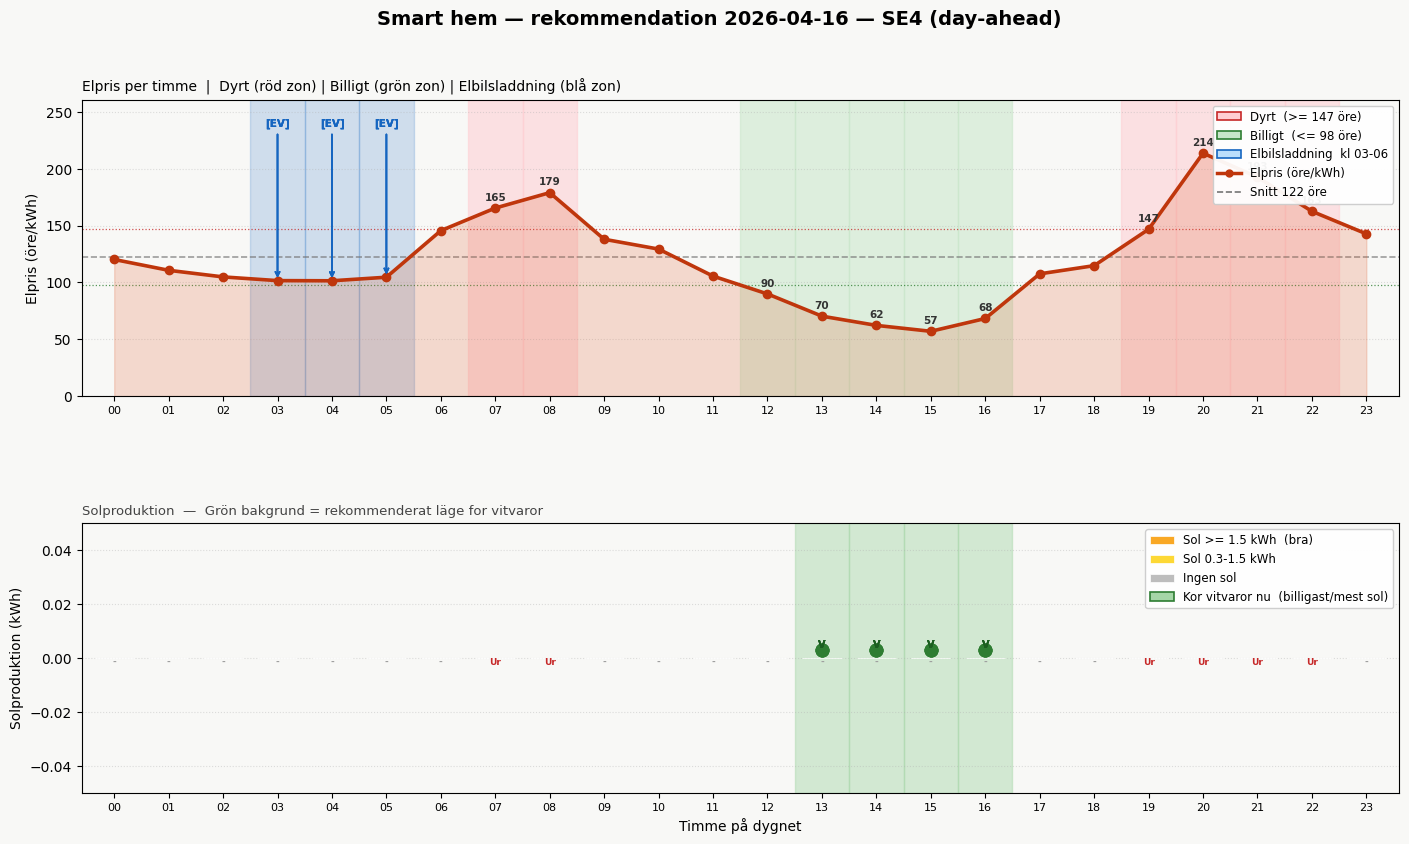

Sparad: steg1_kvallsrapport.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Steg 1 — Solprognos + Day-ahead-priser SE4
# ══════════════════════════════════════════════════════════════════════════════

import datetime as dt

now      = pd.Timestamp.now()
after_14 = now.hour >= 14

# rec_date = den dag vi rekommenderar för
rec_date  = (now + pd.Timedelta(days=1)).date() if after_14 else now.date()
next_date = rec_date + dt.timedelta(days=1)   # dagen efter (för molnkoll)

# ── Hämta priser ───────────────────────────────────────────────────────────────
def fetch_prices(date):
    url = (f"https://www.elprisetjustnu.se/api/v1/prices/"
           f"{pd.Timestamp(date).strftime('%Y/%m-%d')}_SE4.json")
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    return pd.Series(
        {pd.Timestamp(d['time_start']).tz_convert('Europe/Stockholm').tz_localize(None):
         round(d['SEK_per_kWh'] * 100, 2) for d in r.json()},
        name='price_ore'
    ).sort_index()

prices_series = fetch_prices(rec_date)

if after_14:
    print(f"\n📅 Rekommendation för {rec_date} — day-ahead SE4\n")
else:
    print(f"\n📅 Rekommendation för {rec_date} (innevarande dag)")
    print(f"   ℹ️  Morgondagens rekommendation är tillgänglig från 14:00.\n")

# ── 24h-prisarray ──────────────────────────────────────────────────────────────
prices_24 = np.array([
    prices_series.get(pd.Timestamp(rec_date).replace(hour=h), prices_series.mean())
    for h in range(24)
])
avg_p = prices_24.mean()

# ── Bygg solar_24 via modellen ─────────────────────────────────────────────────
def build_hourly_features_for_date(target_date, df_hist, fcst_df):
    """Generaliserad feature-builder för valfritt datum i fcst_df."""
    day_fcst = fcst_df[fcst_df.index.date == target_date].copy()
    if day_fcst.empty:
        return pd.DataFrame()
    hour_arr    = day_fcst.index.hour.to_numpy()
    solar_angle = np.clip(np.sin(np.pi * (hour_arr - 6) / 14), 0, None)
    month          = target_date.month
    clear_sky_peak = 200 + 600 * np.sin(np.pi * (month - 1) / 11)
    cloud_factor_h = 1 - day_fcst['cloud_total_pct'].fillna(100).to_numpy() / 100
    strang_h       = clear_sky_peak * solar_angle * cloud_factor_h
    kt_h           = np.where(solar_angle > 0, cloud_factor_h, 0.0)
    p7d   = df_hist['totalproductionkwh'].tail(7*24).mean()
    p14d  = df_hist['totalproductionkwh'].tail(14*24).mean()
    s7d   = df_hist['strangghiwm2'].tail(7*24).mean()
    rows = []
    for i, ts in enumerate(day_fcst.index):
        if solar_angle[i] <= 0:
            continue
        rows.append({
            'timestamp':      ts,
            'solarangle':     solar_angle[i],
            'strangghiwm2':   strang_h[i],
            'allskykt':       kt_h[i],
            'tempobs':        day_fcst['temp_c'].iloc[i],
            'hour':           ts.hour,
            'month':          ts.month,
            'season_sin':     np.sin(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'season_cos':     np.cos(2 * np.pi * ts.timetuple().tm_yday / 365.25),
            'prod_lag24h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=24),  p7d),
            'prod_lag48h':    lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=48),  p7d),
            'prod_lag168h':   lookup_or_fallback(df_hist, 'totalproductionkwh', ts - pd.Timedelta(hours=168), p7d),
            'strang_lag24h':  lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=24),  s7d),
            'strang_lag48h':  lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=48),  s7d),
            'strang_lag168h': lookup_or_fallback(df_hist, 'strangghiwm2', ts - pd.Timedelta(hours=168), s7d),
            'kt_lag24h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=24),  0.0),
            'kt_lag48h':      lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=48),  0.0),
            'kt_lag168h':     lookup_or_fallback(df_hist, 'allskykt', ts - pd.Timedelta(hours=168), 0.0),
            'prod_roll7d':    p7d,
            'prod_roll14d':   p14d,
            'strang_roll7d':  s7d,
        })
    return pd.DataFrame(rows).set_index('timestamp') if rows else pd.DataFrame()

solar_24 = np.zeros(24)

if after_14:
    # Använd befintlig modellprognos för imorgon
    for ts, row in hourly_pred_tomorrow.iterrows():
        if ts.date() == rec_date:
            solar_24[ts.hour] = max(0.0, row['predicted_kwh'])
else:
    # Kör modellen för idag med dagens SMHI-prognos
    X_today = build_hourly_features_for_date(rec_date, df, fcst_df)
    if not X_today.empty:
        preds_today = np.clip(np.expm1(model.predict(X_today[FEATURES])), 0, None)
        for i, ts in enumerate(X_today.index):
            solar_24[ts.hour] = preds_today[i]

# ── Kolla om dagen efter rec_date är molnig ────────────────────────────────────
nd_fcst          = fcst_df[fcst_df.index.date == next_date]
next_day_cloud   = nd_fcst['cloud_total_pct'].mean() if not nd_fcst.empty else 50.0
next_day_cloudy  = next_day_cloud > 70

# Kvällspriser höga? (kl 18–22 > 120% av snittet)
evening_avg         = prices_24[18:23].mean()
evening_prices_high = evening_avg > avg_p * 1.2

# Sparstrategi: håll batteri om molnigt imorgon OCH kvällspriser är höga
save_battery = next_day_cloudy and evening_prices_high

# ── Trösklar ───────────────────────────────────────────────────────────────────
HIGH_PRICE  = avg_p * 1.20   # öre — "dyrt"
LOW_PRICE   = avg_p * 0.80   # öre — "billigt"
SOLAR_GOOD  = 1.5            # kWh — bra solproduktion
SOLAR_OK    = 0.3            # kWh — lite sol

# ── EV: billigaste 3h-block nattetid (22–07) ──────────────────────────────────
NIGHT_HOURS = list(range(0, 8)) + list(range(22, 24))
EV_DURATION = 3
best_ev_idx = min(
    range(len(NIGHT_HOURS) - EV_DURATION + 1),
    key=lambda i: sum(prices_24[NIGHT_HOURS[i+j]] for j in range(EV_DURATION))
)
ev_hours = set(NIGHT_HOURS[best_ev_idx : best_ev_idx + EV_DURATION])

# ── Vitvaror: 4 bästa timmar dagtid (06–21) ───────────────────────────────────
DAY_HOURS    = list(range(6, 22))
SOLAR_BONUS  = 30   # öre — sol värderas som 30 öre billigare
app_score    = {h: prices_24[h] - solar_24[h] * SOLAR_BONUS for h in DAY_HOURS}
best_app     = set(sorted(DAY_HOURS, key=lambda h: app_score[h])[:4])

# ── Signaler ───────────────────────────────────────────────────────────────────
def sig_bat(h, sol, price):
    if sol >= SOLAR_GOOD:   return '☀️  Ladda med sol'
    if sol >= SOLAR_OK:     return '🌤  Sol täcker last'
    # Natt / låg sol
    if price >= HIGH_PRICE:
        if save_battery and h < 17:
            return '🔋 Spara (sol imorgon låg)'
        return '🔋 Ladda ur (högt pris)'
    if price <= LOW_PRICE:  return '💤 Vänta — lågt pris'
    return '⏸️  Neutral — håll SOC'

def sig_ev(h):
    if h in ev_hours:       return f'🔌 Ladda ({prices_24[h]:.0f} öre)'
    if h in NIGHT_HOURS:    return '😴 Väntar på billigaste blocket'
    return '🚗 Inte hemma/ej aktuellt'

def sig_app(h, sol, price):
    if h not in DAY_HOURS:  return '🌙 Utanför tillåten tid (06–21)'
    if h in best_app:
        if sol >= SOLAR_GOOD: return f'✅ Kör nu! (solel {sol:.1f} kWh)'
        return             f'✅ Kör nu! (billigt {price:.0f} öre)'
    if price >= HIGH_PRICE: return '⛔ Dyrt — vänta'
    return                      f'⏸️  OK men ej optimalt ({price:.0f} öre)'

# ── Beslutstabell ──────────────────────────────────────────────────────────────
print(f"{'━'*95}")
print(f"  REKOMMENDATION TIMME FÖR TIMME  —  {rec_date}  —  SE4")
print(f"{'━'*95}")
print(f"  {'Tim':5}  {'Sol':>5}  {'Öre':>5}  {'Batteri':<28}  {'Elbil':<30}  Vitvaror")
print(f"  {'─'*5}  {'─'*5}  {'─'*5}  {'─'*28}  {'─'*30}  {'─'*28}")
for h in range(24):
    sol   = solar_24[h]
    price = prices_24[h]
    print(f"  {h:02d}:00  {sol:>5.2f}  {price:>5.1f}  "
          f"{sig_bat(h, sol, price):<28}  "
          f"{sig_ev(h):<30}  "
          f"{sig_app(h, sol, price)}")
print(f"{'━'*95}")
print(f"  Sol totalt: {solar_24.sum():.1f} kWh  |  "
      f"Snitt: {avg_p:.1f} öre  |  "
      f"Billigast: {prices_24.min():.1f} öre kl {prices_24.argmin():02d}  |  "
      f"Dyrast: {prices_24.max():.1f} öre kl {prices_24.argmax():02d}")
print(f"  🔌 Elbil: kl {min(ev_hours):02d}:00–{max(ev_hours)+1:02d}:00  |  "
      f"✅ Vitvaror: kl {', '.join(f'{h:02d}' for h in sorted(best_app))}")
if save_battery:
    print(f"  🔋 Imorgon {next_date}: {next_day_cloud:.0f}% moln — spara batteri för kväll/natt.")
else:
    print(f"  ✅ Batteri: ladda ur normalt vid höga priser.")
print(f"{'━'*95}\n")

# ── Kombinerat diagram ────────────────────────────────────────────────────────
from matplotlib.patches import Patch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(17, 9))
fig.patch.set_facecolor('#f8f8f6')
mode_note = " (day-ahead)" if after_14 else " (innevarande dag)"
fig.suptitle(f"Smart hem — rekommendation {rec_date} — SE4{mode_note}",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 1, hspace=0.45, height_ratios=[1.1, 1])
x  = np.arange(24)

# ════════════════════════════════════════════════════════
# PANEL 1 — ELPRIS med zoner och åtgärdsmarkeringar
# ════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#f8f8f6')

# Bakgrundszoner: billigt = grön, dyrt = röd, normalt = vit
for h in x:
    if prices_24[h] <= LOW_PRICE:
        ax1.axvspan(h-0.5, h+0.5, color='#c8e6c9', alpha=0.55, zorder=0)
    elif prices_24[h] >= HIGH_PRICE:
        ax1.axvspan(h-0.5, h+0.5, color='#ffcdd2', alpha=0.55, zorder=0)

# Elbiltimmar — blå vertikal markering
for h in ev_hours:
    ax1.axvspan(h-0.5, h+0.5, color='#1565c0', alpha=0.18, zorder=1)
    for h in ev_hours:
        ax1.annotate(
            '[EV]',
            xy=(h, prices_24[h]),
            xytext=(h, prices_24.max() * 1.10),
            ha='center', va='bottom', fontsize=7.5, fontweight='bold',
            color='#1565c0',
            arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.2),
            zorder=5
    )

# Snittpris-linje
ax1.axhline(avg_p,      color='#757575', linewidth=1.2, linestyle='--', alpha=0.7,
            label=f'Snitt {avg_p:.0f} öre', zorder=2)
ax1.axhline(HIGH_PRICE, color='#c62828', linewidth=0.9, linestyle=':',  alpha=0.8,
            label=f'Hög tröskel {HIGH_PRICE:.0f} öre', zorder=2)
ax1.axhline(LOW_PRICE,  color='#2e7d32', linewidth=0.9, linestyle=':',  alpha=0.8,
            label=f'Låg tröskel {LOW_PRICE:.0f} öre', zorder=2)

# Priset som fylld area
ax1.fill_between(x, prices_24, alpha=0.20, color='#e05c2d', zorder=2)
ax1.plot(x, prices_24, color='#bf360c', linewidth=2.6,
         marker='o', markersize=6, zorder=4, label='Elpris (öre/kWh)')

# Prisvärden på dyra och billiga timmar
for h in x:
    if prices_24[h] >= HIGH_PRICE or prices_24[h] <= LOW_PRICE:
        ax1.text(h, prices_24[h] + avg_p*0.04, f'{prices_24[h]:.0f}',
                 ha='center', va='bottom', fontsize=7.5, color='#333',
                 fontweight='bold', zorder=5)

ax1.set_ylabel('Elpris (öre/kWh)', fontsize=10)
ax1.set_ylim(0, prices_24.max() * 1.22)
ax1.set_xlim(-0.6, 23.6)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{h:02d}' for h in x], fontsize=8)
ax1.set_title('Elpris per timme  |  Dyrt (röd zon) | Billigt (grön zon) | Elbilsladdning (blå zon)',
              fontsize=10, loc='left', pad=6)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

legend1_items = [
    Patch(facecolor='#ffcdd2', edgecolor='#c62828', linewidth=1.2,
          label=f'Dyrt  (>= {HIGH_PRICE:.0f} öre)'),
    Patch(facecolor='#c8e6c9', edgecolor='#2e7d32', linewidth=1.2,
          label=f'Billigt  (<= {LOW_PRICE:.0f} öre)'),
    Patch(facecolor='#bbdefb', edgecolor='#1565c0', linewidth=1.2,
          label=f'Elbilsladdning  kl {min(ev_hours):02d}-{max(ev_hours)+1:02d}'),
    Line2D([0],[0], color='#bf360c', linewidth=2.5,
           marker='o', markersize=5, label='Elpris (öre/kWh)'),
    Line2D([0],[0], color='#757575', linewidth=1.2,
           linestyle='--', label=f'Snitt {avg_p:.0f} öre'),
]
ax1.legend(handles=legend1_items, loc='upper right', fontsize=8.5,
           framealpha=0.95, edgecolor='#ccc')

# ════════════════════════════════════════════════════════
# PANEL 2 — SOLPRODUKTION med vitvaru- och batteri-rekommendationer
# ════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#f8f8f6')

# Bakgrund: vitvarutimmar = grön, sparläge = orange
for h in x:
    if h in best_app:
        ax2.axvspan(h-0.5, h+0.5, color='#a5d6a7', alpha=0.45, zorder=0)

# Solstaplar — färgkodade efter nivå
bar_colors = ['#f9a825' if s >= SOLAR_GOOD
              else '#fdd835' if s >= SOLAR_OK
              else '#bdbdbd' for s in solar_24]

ax2.bar(x, solar_24, color=bar_colors, width=0.72, zorder=2,
        edgecolor='white', linewidth=0.5)

# Vitvaru-ikon ovanför stapeln för de rekommenderade timmarna
for h in best_app:
    ypos = solar_24[h] + solar_24.max() * 0.05 + 0.005
    for h in best_app:
        ypos = solar_24[h] + solar_24.max() * 0.08 + 0.003
        ax2.plot(h, ypos, marker='o', markersize=9,
                color='#2e7d32', zorder=5)
        ax2.text(h, ypos + solar_24.max() * 0.06, 'V',
                ha='center', va='bottom', fontsize=7, fontweight='bold',
                color='#1b5e20', zorder=6)

# Batterisignal som text-badge under x-axeln (via annotation)
def bat_label(h):
    sig = sig_bat(h, solar_24[h], prices_24[h])
    if 'Ladda ur'       in sig: return 'Ur',  '#c62828'
    if 'Ladda med sol'  in sig: return 'Sol', '#f9a825'
    if 'Spara'          in sig: return 'Spar','#e65100'
    if 'tacker'         in sig: return 'OK',  '#388e3c'
    return                             '-',   '#9e9e9e'

for h in x:
    label, color = bat_label(h)
    ax2.text(h, -solar_24.max() * 0.22, label,
             ha='center', va='top', fontsize=6.5,
             fontweight='bold', color=color,
             clip_on=False, zorder=5)
    
ax2.set_ylabel('Solproduktion (kWh)', fontsize=10)
ax2.set_ylim(-solar_24.max()*0.08, solar_24.max() * 1.35)
ax2.set_xlim(-0.6, 23.6)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{h:02d}' for h in x], fontsize=8)
ax2.set_xlabel('Timme på dygnet', fontsize=10)
ax2.set_title('Solproduktion  —  Grön bakgrund = rekommenderat läge för vitvaror',
              fontsize=9.5, loc='left', pad=6, color='#444')
ax2.grid(axis='y', linestyle=':', alpha=0.4)

legend2_items = [
    Patch(facecolor='#f9a825', edgecolor='white', linewidth=0.5,
          label=f'Sol >= {SOLAR_GOOD} kWh  (bra)'),
    Patch(facecolor='#fdd835', edgecolor='white', linewidth=0.5,
          label=f'Sol {SOLAR_OK}-{SOLAR_GOOD} kWh'),
    Patch(facecolor='#bdbdbd', edgecolor='white', linewidth=0.5,
          label='Ingen sol'),
    Patch(facecolor='#a5d6a7', edgecolor='#2e7d32', linewidth=1.2,
          label='Kor vitvaror nu  (billigast/mest sol)'),
]
ax2.legend(handles=legend2_items, loc='upper right', fontsize=8.5,
           framealpha=0.95, edgecolor='#ccc')

plt.savefig('steg1_kvallsrapport.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Sparad: steg1_kvallsrapport.png")

Varmvattenberedaren i min NIBE-bergvärmepump är i nuläget schemalagd på ett statiskt schema (04:00 och 13:30) som statistiskt sett är "bra" tider. I en fullt realiserad version av systemet är varmvattnet en av de viktigaste styrningspunkterna — tack vare tankens termiska tröghet kan uppvärmning förläggas till timmar med hög solproduktion eller lågt spotpris utan att komfortpåverkan uppstår. När AI-modellen fungerar som faktiskt styrning av ett smart hem kommer den att välja optimalt uppvärmningstillfälle på samma sätt som för elbilen och vitvarorna.

In [156]:
# ══════════════════════════════════════════════════════════════════════════════
# Steg 2 — PuLP: 24h smart hem-optimering
# ══════════════════════════════════════════════════════════════════════════════

import pulp

# ── Parametrar ────────────────────────────────────────────────────────────────
H = list(range(24))

BAT_CAP     = 18.0;  BAT_C_MAX = 5.0;  BAT_D_MAX = 5.0
BAT_EFF     = 0.95;  BAT_SOC0  = 9.0;  BAT_SOC_MIN = 1.8
EV_C_MAX    = 11.0;  EV_NEED   = 20.0
EV_HOME     = list(range(0, 7)) + list(range(17, 24))
DISH_KW     = 1.5;   DISH_H    = 2
WASH_KW     = 2.0;   WASH_H    = 2
APP_OK      = list(range(6, 23))
BASE_KW     = 0.5
EXPORT_F    = 0.90

# ── LP-modell ─────────────────────────────────────────────────────────────────
prob = pulp.LpProblem("SmartHome_24h", pulp.LpMinimize)

bat_chg    = pulp.LpVariable.dicts("bc",  H, lowBound=0, upBound=BAT_C_MAX)
bat_dis    = pulp.LpVariable.dicts("bd",  H, lowBound=0, upBound=BAT_D_MAX)
bat_soc    = pulp.LpVariable.dicts("bs",  H, lowBound=BAT_SOC_MIN, upBound=BAT_CAP)
ev_chg     = pulp.LpVariable.dicts("ev",  H, lowBound=0, upBound=EV_C_MAX)
dish       = pulp.LpVariable.dicts("di",  H, cat='Binary')
wash       = pulp.LpVariable.dicts("wa",  H, cat='Binary')
grid_imp   = pulp.LpVariable.dicts("gi",  H, lowBound=0)
grid_exp   = pulp.LpVariable.dicts("ge",  H, lowBound=0)

# Sol delas explicit upp — hindrar implicit nätladdning av batteriet
sol_direct = pulp.LpVariable.dicts("sd",  H, lowBound=0)  # sol → last / export
sol_to_bat = pulp.LpVariable.dicts("sb",  H, lowBound=0)  # sol → batteri ONLY

# ── Mål: minimera nettokostnad ────────────────────────────────────────────────
prob += pulp.lpSum(
    grid_imp[t] * prices_24[t] / 100
    - grid_exp[t] * prices_24[t] * EXPORT_F / 100
    for t in H
)

# ── Constraints ───────────────────────────────────────────────────────────────
for t in H:
    # Sol-fördelning får ej överstiga tillgänglig sol
    prob += sol_direct[t] + sol_to_bat[t] <= solar_24[t]

    # Batteri laddas BARA från sol — aldrig från nät
    prob += bat_chg[t] == sol_to_bat[t]

    # Energibalans: last täcks av sol_direct + batteri-urladdning + nätimport
    # (grid_imp kan INTE flöda via batteriet — det är nu fysiskt omöjligt)
    prob += (sol_direct[t] + bat_dis[t] + grid_imp[t] ==
             BASE_KW + ev_chg[t] + dish[t] * DISH_KW + wash[t] * WASH_KW)

    # Export = sol som varken används direkt eller lagras i batteri
    prob += grid_exp[t] == solar_24[t] - sol_direct[t] - sol_to_bat[t]

    # Batteri SOC-uppdatering
    prev = BAT_SOC0 if t == 0 else bat_soc[t - 1]
    prob += bat_soc[t] == prev + bat_chg[t] * BAT_EFF - bat_dis[t] / BAT_EFF

    # Elbil bara hemma
    if t not in EV_HOME:
        prob += ev_chg[t] == 0
    # Vitvaror bara dagtid
    if t not in APP_OK:
        prob += dish[t] == 0
        prob += wash[t] == 0

# Antal körningscykler och elbilsbehov
prob += pulp.lpSum(dish[t] for t in H) == DISH_H
prob += pulp.lpSum(wash[t] for t in H) == WASH_H
prob += pulp.lpSum(ev_chg[t] for t in EV_HOME) >= EV_NEED

status = prob.solve(pulp.PULP_CBC_CMD(msg=0))
print(f"Optimeringsstatus: {pulp.LpStatus[status]}")

# ── Resultat-DataFrame ────────────────────────────────────────────────────────
res = pd.DataFrame({
    'solar':      solar_24,
    'price':      prices_24,
    'sol_direct': [sol_direct[t].varValue or 0 for t in H],
    'sol_to_bat': [sol_to_bat[t].varValue or 0 for t in H],
    'bat_chg':    [bat_chg[t].varValue    or 0 for t in H],
    'bat_dis':    [bat_dis[t].varValue    or 0 for t in H],
    'bat_soc':    [bat_soc[t].varValue    or 0 for t in H],
    'ev_chg':     [ev_chg[t].varValue     or 0 for t in H],
    'dish':       [dish[t].varValue       or 0 for t in H],
    'wash':       [wash[t].varValue       or 0 for t in H],
    'grid_imp':   [grid_imp[t].varValue   or 0 for t in H],
    'grid_exp':   [grid_exp[t].varValue   or 0 for t in H],
}, index=H)
res['cost_kr'] = (res['grid_imp'] * res['price'] / 100
                  - res['grid_exp'] * res['price'] * EXPORT_F / 100)
opt_cost = res['cost_kr'].sum()

# Verifiering: batteri ska aldrig laddas mer än sol tillgänglig
assert (res['bat_chg'] > res['solar'] + 0.01).sum() == 0, \
    "VARNING: Batteri laddas mer an tillganglig sol!"

# ── Utskrift ──────────────────────────────────────────────────────────────────
print(f"\n{'━'*80}")
print(f"  OPTIMERAT 24h-SCHEMA  —  {rec_date}  —  SE4")
print(f"{'━'*80}")
print(f"  {'Tim':>4}  {'Pris':>5}  {'Sol':>5}  {'S>Bat':>5}  "
      f"{'Nat+':>5}  {'Nat-':>5}  {'Bat+':>5}  {'Bat-':>5}  "
      f"{'SOC':>5}  {'Elbil':>5}  Disk  Tvatt")
print(f"  {'─'*4}  {'─'*5}  {'─'*5}  {'─'*5}  "
      f"{'─'*5}  {'─'*5}  {'─'*5}  {'─'*5}  "
      f"{'─'*5}  {'─'*5}  {'─'*4}  {'─'*5}")
for t, row in res.iterrows():
    d = '[X]' if row['dish'] > 0.5 else '   '
    w = '[X]' if row['wash'] > 0.5 else '   '
    print(f"  {t:02d}:00  {row['price']:>5.1f}  {row['solar']:>5.2f}  "
          f"{row['sol_to_bat']:>5.2f}  "
          f"{row['grid_imp']:>5.2f}  {row['grid_exp']:>5.2f}  "
          f"{row['bat_chg']:>5.2f}  {row['bat_dis']:>5.2f}  "
          f"{row['bat_soc']:>5.1f}  {row['ev_chg']:>5.2f}  "
          f"  {d}    {w}")
print(f"{'━'*80}")
print(f"  Nettokostnad: {opt_cost:.2f} kr  |  "
      f"Import: {res['grid_imp'].sum():.1f} kWh  |  "
      f"Export: {res['grid_exp'].sum():.1f} kWh  |  "
      f"Sol till bat: {res['sol_to_bat'].sum():.1f} kWh")
print(f"{'━'*80}")
print(f"\n  Batteriet laddas uteslutande fran sol. Ingen natladding mojlig.")

Optimeringsstatus: Optimal

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  OPTIMERAT 24h-SCHEMA  —  2025-08-17  —  SE4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Tim   Pris    Sol  S>Bat   Nat+   Nat-   Bat+   Bat-    SOC  Elbil  Disk  Tvatt
  ────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ─────  ────  ─────
  00:00   80.0   0.00   0.00   0.00   0.00   0.00   4.36    4.4   3.86              
  01:00   73.4   0.00   0.00   0.00   0.00   0.00   0.50    3.9   0.00              
  02:00   74.6   0.00   0.00   0.00   0.00   0.00   0.50    3.4   0.00              
  03:00   74.3   0.00   0.00   0.00   0.00   0.00   0.50    2.8   0.00              
  04:00   63.3   0.00   0.00   0.00   0.00   0.00   0.50    2.3   0.00              
  05:00   40.2   0.02   0.00   0.00   0.00   0.00   0.48    1.8   0.00              
  06:00   37.6   0.16   0.00   4.59   0.00   0.00   0.00    1.8   4.25              
  0

In [171]:
# Månadsanalys 2023-07 → 2025-12 — faktisk besparing med optimering ──

PERIODSTART = pd.Timestamp('2023-07-01').date()
PERIODEND = pd.Timestamp('2025-12-31').date()

perioddates = sorted(set(
d for d in dfmaster.index.date
if PERIODSTART <= d <= PERIODEND
))

print(f"Period {perioddates} - {perioddates[-1]} {len(perioddates)} dagar")
print("Kör optimering per dag...", end="", flush=True)

# Kör backtest för hela perioden
# monthlyresults = ]
# dailyrows = ]

for day in perioddates:
daydata = dfmaster[dfmaster.index.date == day]
if len(daydata) < 20:
continue

solarr = np.array([
daydata.loc[daydata.index.hour == h, 'total_production_kwh'].sum()
for h in range(24)
])

pricearr = np.array([
daydata.loc[daydata.index.hour == h, 'price_total_ore'].mean()
if h in daydata.index.hour else np.nan
for h in range(24)
])

if np.isnan(pricearr).any():
continue

out = run_optimizer(solarr, pricearr)
if out is None:
continue

ocost, ncost, oimp, nimp = out

dailyrows.append({
'datum': day,
'ar': day.year,
'manad': day.month,
'armanad': f"{day.year}-{day.month:02d}",
'solkwh': solarr.sum(),
'snittprisore': pricearr.mean(),
'naivekr': ncost,
'optkr': ocost,
'besparingkr': ncost - ocost,
'naiveimpkwh': nimp,
'optimpkwh': oimp,
})
print(".", end="", flush=True)

print(f" klar! {len(dailyrows)} dagar")

dfdaily = pd.DataFrame(dailyrows)

# Aggregera per månad
dfmonthly = (
dfdaily
.groupby('armanad')
.agg(
antaldagar = ('datum', 'count'),
solkwh = ('solkwh', 'sum'),
snittprisore= ('snittprisore','mean'),
naivekr = ('naivekr', 'sum'),
optkr = ('optkr', 'sum'),
besparingkr = ('besparingkr', 'sum'),
naiveimpkwh = ('naiveimpkwh', 'sum'),
optimpkwh = ('optimpkwh', 'sum'),
)
.reset_index()
)

dfmonthly['besparingpct'] = (
dfmonthly['besparingkr'] / dfmonthly['naivekr'].replace(0, np.nan) * 100
).fillna(0)
dfmonthly['kumulativkr'] = dfmonthly['besparingkr'].cumsum()

# Spara
dfmonthly.to_csv(f"{OUTPUTDIR}manadsbesparing.csv", index=False, encoding='utf-8-sig')
dfdaily.to_csv( f"{OUTPUTDIR}dagligbesparingfull.csv", index=False, encoding='utf-8-sig')
print(f"manadsbesparing.csv {len(dfmonthly)} månader dagligbesparingfull.csv {len(dfdaily)} dagar")

IndentationError: expected an indented block after 'for' statement on line 18 (13238001.py, line 19)

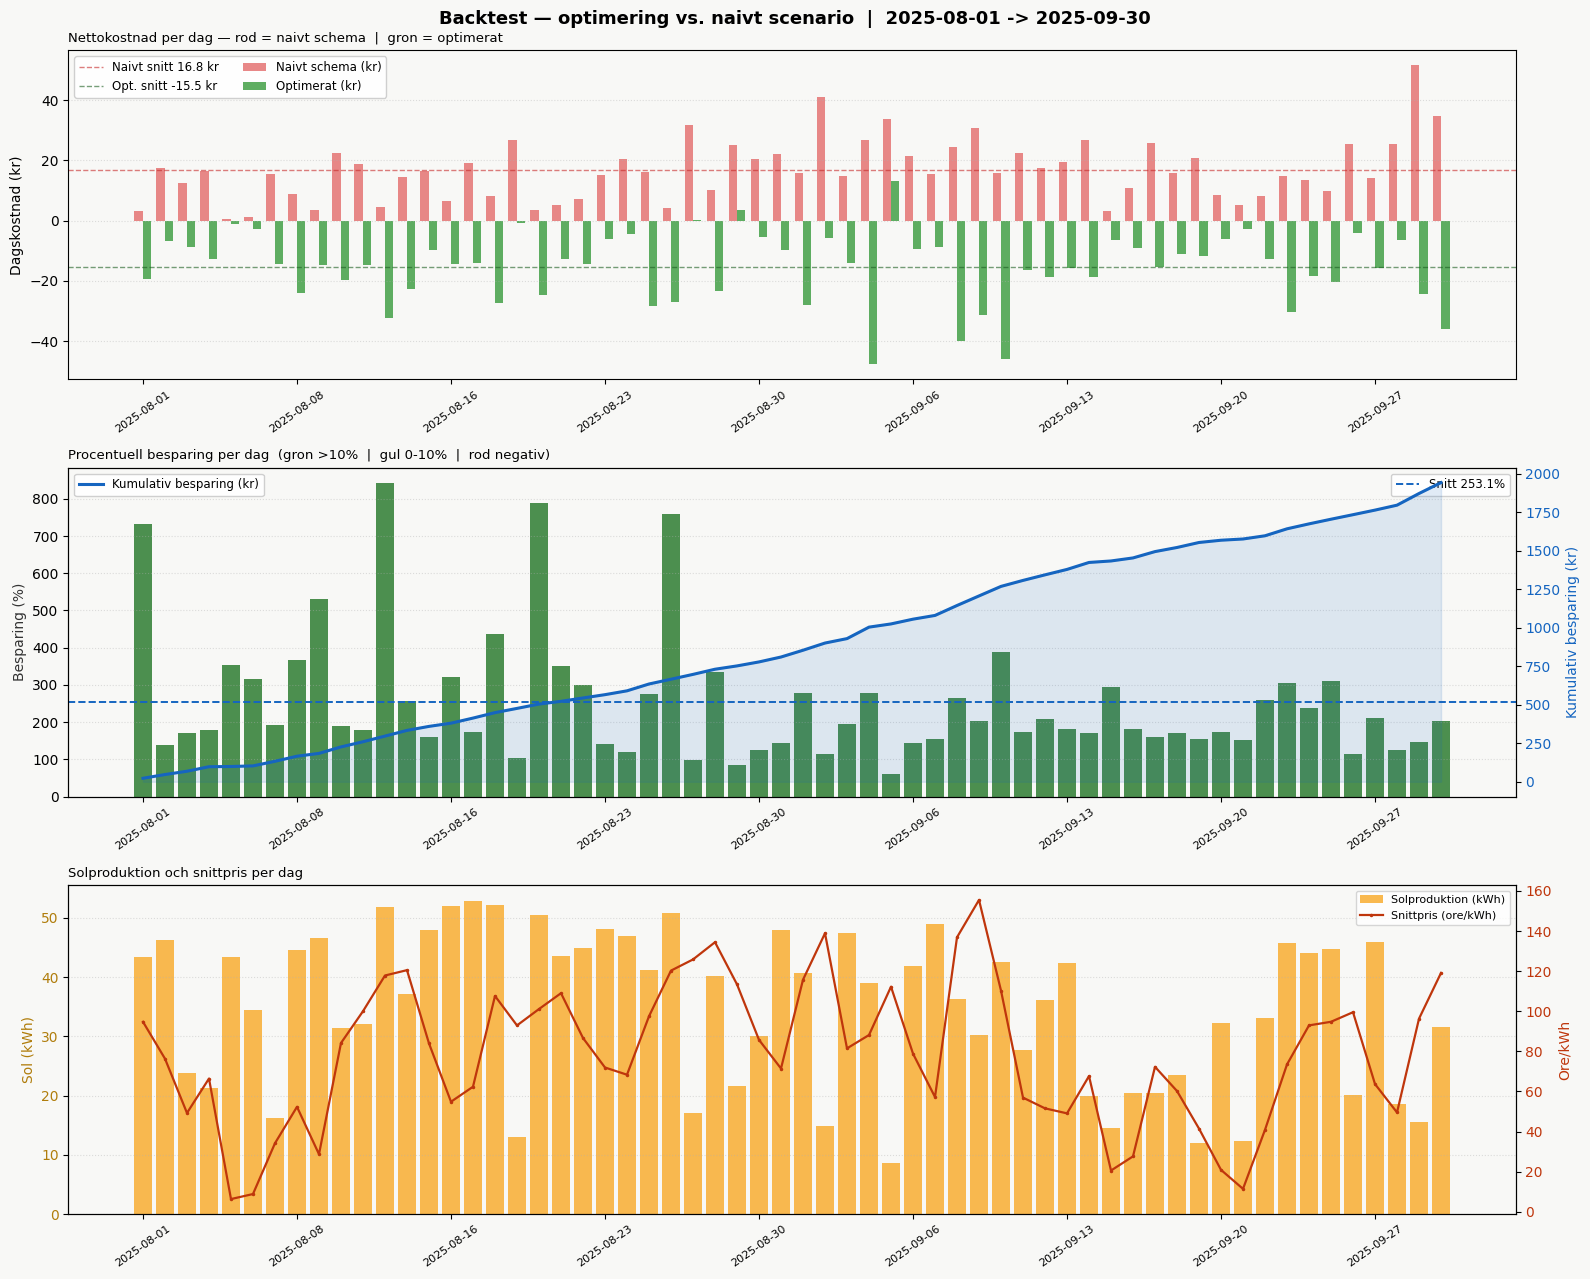

Sparad: steg3_backtest.png


In [167]:
# ── Visualisering (ersätt det gamla fig/axes-blocket) ─────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#f8f8f6')
fig.suptitle(f'Backtest — optimering vs. naivt scenario  |  '
             f'{test_dates[0]} -> {test_dates[-1]}',
             fontsize=13, fontweight='bold')

x_bt   = np.arange(len(bt))
x_days = bt.index
tick_step = max(1, len(bt) // 8)

# ── Panel 1 — Naiv vs. optimerad kostnad per dag (grupperade staplar) ──────────
ax = axes[0]
ax.set_facecolor('#f8f8f6')
w = 0.38
ax.bar(x_bt - w/2, bt['naive_kr'],   width=w, color='#e57373', alpha=0.85,
       label='Naivt schema (kr)')
ax.bar(x_bt + w/2, bt['opt_kr'],     width=w, color='#43a047', alpha=0.85,
       label='Optimerat (kr)')
ax.axhline(bt['naive_kr'].mean(), color='#c62828', linewidth=1.0,
           linestyle='--', alpha=0.6, label=f'Naivt snitt {bt["naive_kr"].mean():.1f} kr')
ax.axhline(bt['opt_kr'].mean(),   color='#1b5e20', linewidth=1.0,
           linestyle='--', alpha=0.6, label=f'Opt. snitt {bt["opt_kr"].mean():.1f} kr')
ax.set_ylabel('Dagskostnad (kr)')
ax.set_title('Nettokostnad per dag — rod = naivt schema  |  gron = optimerat',
             fontsize=9.5, loc='left')
ax.legend(fontsize=8.5, framealpha=0.92, ncol=2)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_xticks(x_bt[::tick_step])
ax.set_xticklabels([str(d) for d in x_days[::tick_step]], rotation=35, fontsize=8)

# ── Panel 2 — Besparing % + kumulativ kr ──────────────────────────────────────
ax = axes[1]
ax.set_facecolor('#f8f8f6')

bt['besparing_pct'] = (bt['besparing_kr'] / bt['naive_kr'].replace(0, np.nan) * 100).fillna(0)
bar_colors = ['#2e7d32' if v >= 10 else '#f9a825' if v >= 0 else '#c62828'
              for v in bt['besparing_pct']]
ax.bar(x_bt, bt['besparing_pct'], color=bar_colors, alpha=0.85, width=0.8)
ax.axhline(bt['besparing_pct'].mean(), color='#1565c0', linewidth=1.4,
           linestyle='--', label=f'Snitt {bt["besparing_pct"].mean():.1f}%')
ax.set_ylabel('Besparing (%)', color='#333')
ax.set_title('Procentuell besparing per dag  (gron >10%  |  gul 0-10%  |  rod negativ)',
             fontsize=9.5, loc='left')
ax.legend(fontsize=8.5, framealpha=0.92)
ax.grid(axis='y', linestyle=':', alpha=0.4)

ax2b = ax.twinx()
ax2b.plot(x_bt, bt['kumulativ_besparing_kr'], color='#1565c0',
          linewidth=2.2, label='Kumulativ besparing (kr)')
ax2b.fill_between(x_bt, bt['kumulativ_besparing_kr'], alpha=0.12, color='#1565c0')
ax2b.set_ylabel('Kumulativ besparing (kr)', color='#1565c0')
ax2b.tick_params(axis='y', labelcolor='#1565c0')
ax2b.legend(loc='upper left', fontsize=8.5, framealpha=0.92)
ax.set_xticks(x_bt[::tick_step])
ax.set_xticklabels([str(d) for d in x_days[::tick_step]], rotation=35, fontsize=8)

# ── Panel 3 — Solproduktion + snittpris ───────────────────────────────────────
ax = axes[2]
ax.set_facecolor('#f8f8f6')
ax.bar(x_bt, bt['sol_kwh'], color='#f9a825', alpha=0.8, width=0.8,
       label='Solproduktion (kWh)')
ax.set_ylabel('Sol (kWh)', color='#b07d0c')
ax.tick_params(axis='y', labelcolor='#b07d0c')
ax3b = ax.twinx()
ax3b.plot(x_bt, bt['snittpris_ore'], color='#bf360c', linewidth=1.6,
          marker='.', markersize=3, label='Snittpris (ore/kWh)')
ax3b.set_ylabel('Ore/kWh', color='#bf360c')
ax3b.tick_params(axis='y', labelcolor='#bf360c')
ax.set_title('Solproduktion och snittpris per dag', fontsize=9.5, loc='left')
ax.set_xticks(x_bt[::tick_step])
ax.set_xticklabels([str(d) for d in x_days[::tick_step]], rotation=35, fontsize=8)

lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax3b.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, loc='upper right', fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('steg3_backtest.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Sparad: steg3_backtest.png")

In [172]:
# Projektrapport + CSV-export för Power BI

OUTPUT_DIR = "PowerBI_export"
os.makedirs(OUTPUT_DIR, exist_ok=True)

export_ts = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')

# ══ 1. TIMVIS REKOMMENDATION (från Steg 1) ════════════════════════════════════
df_rec = pd.DataFrame({
    'datum':           str(rec_date),
    'timme':           [f'{h:02d}:00' for h in range(24)],
    'sol_kwh':         solar_24,
    'pris_ore':        prices_24,
    'bat_signal':      [sig_bat(h, solar_24[h], prices_24[h]) for h in range(24)],
    'ev_signal':       [sig_ev(h) for h in range(24)],
    'vitvaror_signal': [sig_app(h, solar_24[h], prices_24[h]) for h in range(24)],
    'ev_laddning':     [1 if h in ev_hours  else 0 for h in range(24)],
    'vitvaror_on':     [1 if h in best_app  else 0 for h in range(24)],
    'hog_pris':        [1 if prices_24[h] >= HIGH_PRICE else 0 for h in range(24)],
    'lag_pris':        [1 if prices_24[h] <= LOW_PRICE  else 0 for h in range(24)],
    'bra_sol':         [1 if solar_24[h] >= SOLAR_GOOD  else 0 for h in range(24)],
    'exporterad_ts':   export_ts,
})
df_rec.to_csv(f'{OUTPUT_DIR}/rekommendation_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ rekommendation_timvis.csv ({len(df_rec)} rader)")

# ══ 2. OPTIMERINGSSCHEMA (från Steg 2 — PuLP) ═════════════════════════════════
df_opt = res.copy().reset_index()
df_opt.insert(0, 'datum', str(rec_date))
df_opt.insert(1, 'timme', [f'{h:02d}:00' for h in range(24)])
df_opt['disk_on']  = df_opt['dish'].round().astype(int)
df_opt['tvätt_on'] = df_opt['wash'].round().astype(int)
df_opt['exporterad_ts'] = export_ts
df_opt.drop(columns=['index'], errors='ignore', inplace=True)
df_opt.to_csv(f'{OUTPUT_DIR}/optimering_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ optimering_timvis.csv ({len(df_opt)} rader)")

# ══ 3. NAIVT SCENARIO (beräkna) ═══════════════════════════════════════════════
naive_load = np.full(24, BASE_KW)
naive_load[12] += DISH_KW;  naive_load[13] += DISH_KW
naive_load[13] += WASH_KW;  naive_load[14] += WASH_KW
ev_per_h = EV_NEED / 2
naive_load[17] += ev_per_h; naive_load[18] += ev_per_h

naive_imp  = np.maximum(0, naive_load - solar_24)
naive_exp  = np.maximum(0, solar_24 - naive_load)
naive_cost = (naive_imp * prices_24 / 100).sum() - (naive_exp * prices_24 * EXPORT_F / 100).sum()
naive_self_pct = (np.minimum(solar_24, naive_load).sum() / max(solar_24.sum(), 0.001)) * 100

opt_self_pct = (max(0, solar_24.sum() - res['grid_exp'].sum()) / max(solar_24.sum(), 0.001)) * 100
saving_kr    = naive_cost - opt_cost
saving_pct   = (saving_kr / max(abs(naive_cost), 0.001)) * 100

# ══ 4. NYCKELTAL-SAMMANFATTNING ═══════════════════════════════════════════════
try:
    n_train = int((dfh.index < pd.Timestamp(TRAIN_CUTOFF)).sum())
    n_test  = int((dfh.index >= pd.Timestamp(TRAIN_CUTOFF)).sum())
    data_from = str(dfh.index.min().date())
    data_to   = str(dfh.index.max().date())
except:
    n_train = n_test = 0
    data_from = data_to = ''

df_kpi = pd.DataFrame([
    # Modell
    {'kategori': 'Modell',      'nyckeltal': 'Algoritm',             'värde_text': 'LightGBM (Optuna)',  'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Träningsperiod',       'värde_text': data_from,            'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Testperiod start',     'värde_text': TRAIN_CUTOFF,         'värde_num': None},
    {'kategori': 'Modell',      'nyckeltal': 'Träningstimmar',       'värde_text': str(n_train),         'värde_num': n_train},
    {'kategori': 'Modell',      'nyckeltal': 'Testtimmar',           'värde_text': str(n_test),          'värde_num': n_test},
    # Prognos
    {'kategori': 'Prognos',     'nyckeltal': 'Datum',                'värde_text': str(rec_date),        'värde_num': None},
    {'kategori': 'Prognos',     'nyckeltal': 'Sol total kWh',        'värde_text': f'{solar_24.sum():.1f}', 'värde_num': round(solar_24.sum(), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Snittpris öre',        'värde_text': f'{avg_p:.1f}',       'värde_num': round(avg_p, 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Maxpris öre',          'värde_text': f'{prices_24.max():.1f}', 'värde_num': round(float(prices_24.max()), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Minpris öre',          'värde_text': f'{prices_24.min():.1f}', 'värde_num': round(float(prices_24.min()), 2)},
    {'kategori': 'Prognos',     'nyckeltal': 'Molntäckning imorgon %','värde_text': f'{next_day_cloud:.0f}', 'värde_num': round(next_day_cloud, 1)},
    # Utan optimering
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nätimport kWh',        'värde_text': f'{naive_imp.sum():.1f}',  'värde_num': round(float(naive_imp.sum()), 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nätexport kWh',        'värde_text': f'{naive_exp.sum():.1f}',  'värde_num': round(float(naive_exp.sum()), 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Egenförbrukning %',    'värde_text': f'{naive_self_pct:.1f}',   'värde_num': round(naive_self_pct, 2)},
    {'kategori': 'Utan opt.',   'nyckeltal': 'Nettokostnad kr',      'värde_text': f'{naive_cost:.2f}',       'värde_num': round(naive_cost, 4)},
    # Med optimering
    {'kategori': 'Med opt.',    'nyckeltal': 'Nätimport kWh',        'värde_text': f'{res["grid_imp"].sum():.1f}', 'värde_num': round(float(res['grid_imp'].sum()), 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Nätexport kWh',        'värde_text': f'{res["grid_exp"].sum():.1f}', 'värde_num': round(float(res['grid_exp'].sum()), 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Egenförbrukning %',    'värde_text': f'{opt_self_pct:.1f}',     'värde_num': round(opt_self_pct, 2)},
    {'kategori': 'Med opt.',    'nyckeltal': 'Nettokostnad kr',      'värde_text': f'{opt_cost:.2f}',         'värde_num': round(opt_cost, 4)},
    # Besparing
    {'kategori': 'Besparing',   'nyckeltal': 'Kr per dag',           'värde_text': f'{saving_kr:.2f}',        'värde_num': round(saving_kr, 4)},
    {'kategori': 'Besparing',   'nyckeltal': 'Procent',              'värde_text': f'{saving_pct:.1f}%',      'värde_num': round(saving_pct, 2)},
    {'kategori': 'Besparing',   'nyckeltal': 'Estimerat per månad kr','värde_text': f'{saving_kr*30:.0f}',    'värde_num': round(saving_kr * 30, 2)},
    {'kategori': 'Besparing',   'nyckeltal': 'Estimerat per år kr',  'värde_text': f'{saving_kr*365:.0f}',   'värde_num': round(saving_kr * 365, 2)},
])
df_kpi['exporterad_ts'] = export_ts
df_kpi.to_csv(f'{OUTPUT_DIR}/nyckeltal.csv', index=False, encoding='utf-8-sig')
print(f"✅ nyckeltal.csv ({len(df_kpi)} rader)")

# ══ 5. TIMVIS JÄMFÖRELSE utan/med opt (för stapeldiagram i Power BI) ══════════
df_jmf = pd.DataFrame({
    'datum':            str(rec_date),
    'timme':            [f'{h:02d}:00' for h in range(24)],
    'sol_kwh':          solar_24,
    'pris_ore':         prices_24,
    'naiv_import_kwh':  naive_imp,
    'naiv_export_kwh':  naive_exp,
    'naiv_last_kwh':    naive_load,
    'naiv_kostnad_kr':  naive_imp * prices_24 / 100 - naive_exp * prices_24 * EXPORT_F / 100,
    'opt_import_kwh':   res['grid_imp'].values,
    'opt_export_kwh':   res['grid_exp'].values,
    'opt_sol_till_bat_kwh': res['sol_to_bat'].values,  
    'opt_bat_soc_kwh':  res['bat_soc'].values,
    'opt_bat_chg_kwh':  res['bat_chg'].values,
    'opt_bat_dis_kwh':  res['bat_dis'].values,
    'opt_ev_kwh':       res['ev_chg'].values,
    'opt_kostnad_kr':   res['cost_kr'].values,
    'exporterad_ts':    export_ts,
})
df_jmf.to_csv(f'{OUTPUT_DIR}/jamforelse_timvis.csv', index=False, encoding='utf-8-sig')
print(f"✅ jamforelse_timvis.csv ({len(df_jmf)} rader)")

# ══ 6. UTSKRIFT ═══════════════════════════════════════════════════════════════
print(f"\n{'═'*60}")
print(f"  PROJEKTRAPPORT — {export_ts}")
print(f"{'═'*60}")
print(f"  Prognos {rec_date}: {solar_24.sum():.1f} kWh sol  |  "
      f"Snittpris: {avg_p:.1f} öre")
print(f"  {'Nyckeltal':<30} {'Utan opt.':>10}  {'Med opt.':>10}  {'Diff':>8}")
print(f"  {'─'*30}  {'─'*10}  {'─'*10}  {'─'*8}")
print(f"  {'Nätimport (kWh)':<30} {naive_imp.sum():>10.1f}  {res['grid_imp'].sum():>10.1f}  "
      f"{naive_imp.sum()-res['grid_imp'].sum():>+8.1f}")
print(f"  {'Nätexport (kWh)':<30} {naive_exp.sum():>10.1f}  {res['grid_exp'].sum():>10.1f}  "
      f"{res['grid_exp'].sum()-naive_exp.sum():>+8.1f}")
print(f"  {'Egenförbrukning (%)':<30} {naive_self_pct:>10.1f}  {opt_self_pct:>10.1f}  "
      f"{opt_self_pct-naive_self_pct:>+8.1f}")
print(f"  {'Nettokostnad (kr)':<30} {naive_cost:>10.2f}  {opt_cost:>10.2f}  "
      f"{saving_kr:>+8.2f}")
print(f"{'═'*60}")
print(f"  💰 Besparing: {saving_kr:.2f} kr för denna toppdag")
print(f"{'═'*60}")
print(f"\n📁 Filer sparade i mapp: {os.path.abspath(OUTPUT_DIR)}/")
print(f"   rekommendation_timvis.csv  — timvisa signaler för batteri/elbil/vitvaror")
print(f"   optimering_timvis.csv      — PuLP-schema med alla energiflöden")
print(f"   jamforelse_timvis.csv      — utan vs. med optimering timme för timme")
print(f"   nyckeltal.csv              — KPI-tabell för Power BI-kort")

✅ rekommendation_timvis.csv (24 rader)
✅ optimering_timvis.csv (24 rader)
✅ nyckeltal.csv (23 rader)
✅ jamforelse_timvis.csv (24 rader)

════════════════════════════════════════════════════════════
  PROJEKTRAPPORT — 2026-04-16 16:31
════════════════════════════════════════════════════════════
  Prognos 2025-08-17: 52.9 kWh sol  |  Snittpris: 56.5 öre
  Nyckeltal                       Utan opt.    Med opt.      Diff
  ──────────────────────────────  ──────────  ──────────  ────────
  Nätimport (kWh)                      24.4         9.9     +14.5
  Nätexport (kWh)                      38.3        29.0      -9.4
  Egenförbrukning (%)                  27.5        45.2     +17.7
  Nettokostnad (kr)                   19.71       -2.81    +22.52
════════════════════════════════════════════════════════════
  💰 Besparing: 22.52 kr för denna toppdag
════════════════════════════════════════════════════════════

📁 Filer sparade i mapp: c:\Dropbox\Dropbox\BI-analyst\AI och IoT\AI_IoT_Kunskapskont

In [153]:
# ══════════════════════════════════════════════════════════════════════════════
# Demo-export — välj en historisk dag med bra sol för Power BI-dashboard
# ══════════════════════════════════════════════════════════════════════════════

# Hitta den bästa soldag i backtestdata
best_sol_day = bt['sol_kwh'].idxmax()
print(f"Bästa soldag i backtest: {best_sol_day}  ({bt.loc[best_sol_day,'sol_kwh']:.1f} kWh)")

# Visa topp 5 så du kan välja
print("\nTopp 5 soldagar i backtest:")
print(bt['sol_kwh'].nlargest(5).to_string())

DEMO_DATE = best_sol_day   # eller hårdkoda t.ex.: datetime.date(2025, 8, 12)

Bästa soldag i backtest: 2025-08-17  (52.9 kWh)

Topp 5 soldagar i backtest:
datum
2025-08-17   52.884
2025-08-18   52.112
2025-08-16   51.966
2025-08-13   51.880
2025-08-26   50.818


In [168]:
# ── Bygg om solar_24 och prices_24 för demo-dagen ─────────────────────────────
demo_data  = df_master[df_master.index.date == DEMO_DATE]

solar_24   = np.array([
    demo_data.loc[demo_data.index.hour == h, 'total_production_kwh'].sum()
    for h in range(24)
])

try:
    prices_series_demo = fetch_prices(DEMO_DATE)
    prices_24 = np.array([
        prices_series_demo.get(pd.Timestamp(DEMO_DATE).replace(hour=h),
                               prices_series_demo.mean())
        for h in range(24)
    ])
except Exception:
    # API har inte gamla priser — använd prisdata från df_master
    prices_24 = np.array([
        demo_data.loc[demo_data.index.hour == h, 'price_total_ore'].mean()
        if h in demo_data.index.hour else avg_p
        for h in range(24)
    ])

rec_date = DEMO_DATE
avg_p    = prices_24.mean()
HIGH_PRICE = avg_p * 1.20
LOW_PRICE  = avg_p * 0.80

print(f"\nDemo-dag: {DEMO_DATE}")
print(f"Sol: {solar_24.sum():.1f} kWh  |  Pris snitt: {avg_p:.1f} öre  "
      f"|  Min: {prices_24.min():.1f}  |  Max: {prices_24.max():.1f}")

# ── Räkna om EV och vitvaror med nya värden ───────────────────────────────────
best_ev_idx = min(
    range(len(NIGHT_HOURS) - EV_DURATION + 1),
    key=lambda i: sum(prices_24[NIGHT_HOURS[i+j]] for j in range(EV_DURATION))
)
ev_hours = set(NIGHT_HOURS[best_ev_idx : best_ev_idx + EV_DURATION])

app_score = {h: prices_24[h] - solar_24[h] * SOLAR_BONUS for h in DAY_HOURS}
best_app  = set(sorted(DAY_HOURS, key=lambda h: app_score[h])[:4])

# Kör Steg 2 (PuLP) med ny solar_24 och prices_24
# ... (Steg 2-cellen körs om automatiskt om du kör dem i ordning)

# ── Kör sedan Steg 4 (export) direkt efter ────────────────────────────────────



Demo-dag: 2025-08-17
Sol: 52.9 kWh  |  Pris snitt: 56.5 öre  |  Min: -0.0  |  Max: 124.0


Period: 2023-07-01 -> 2025-12-31  (915 dagar)
Kör optimering per dag........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................... klar! (872 dagar)

Sparade: manadsbesparing.csv (30 mana

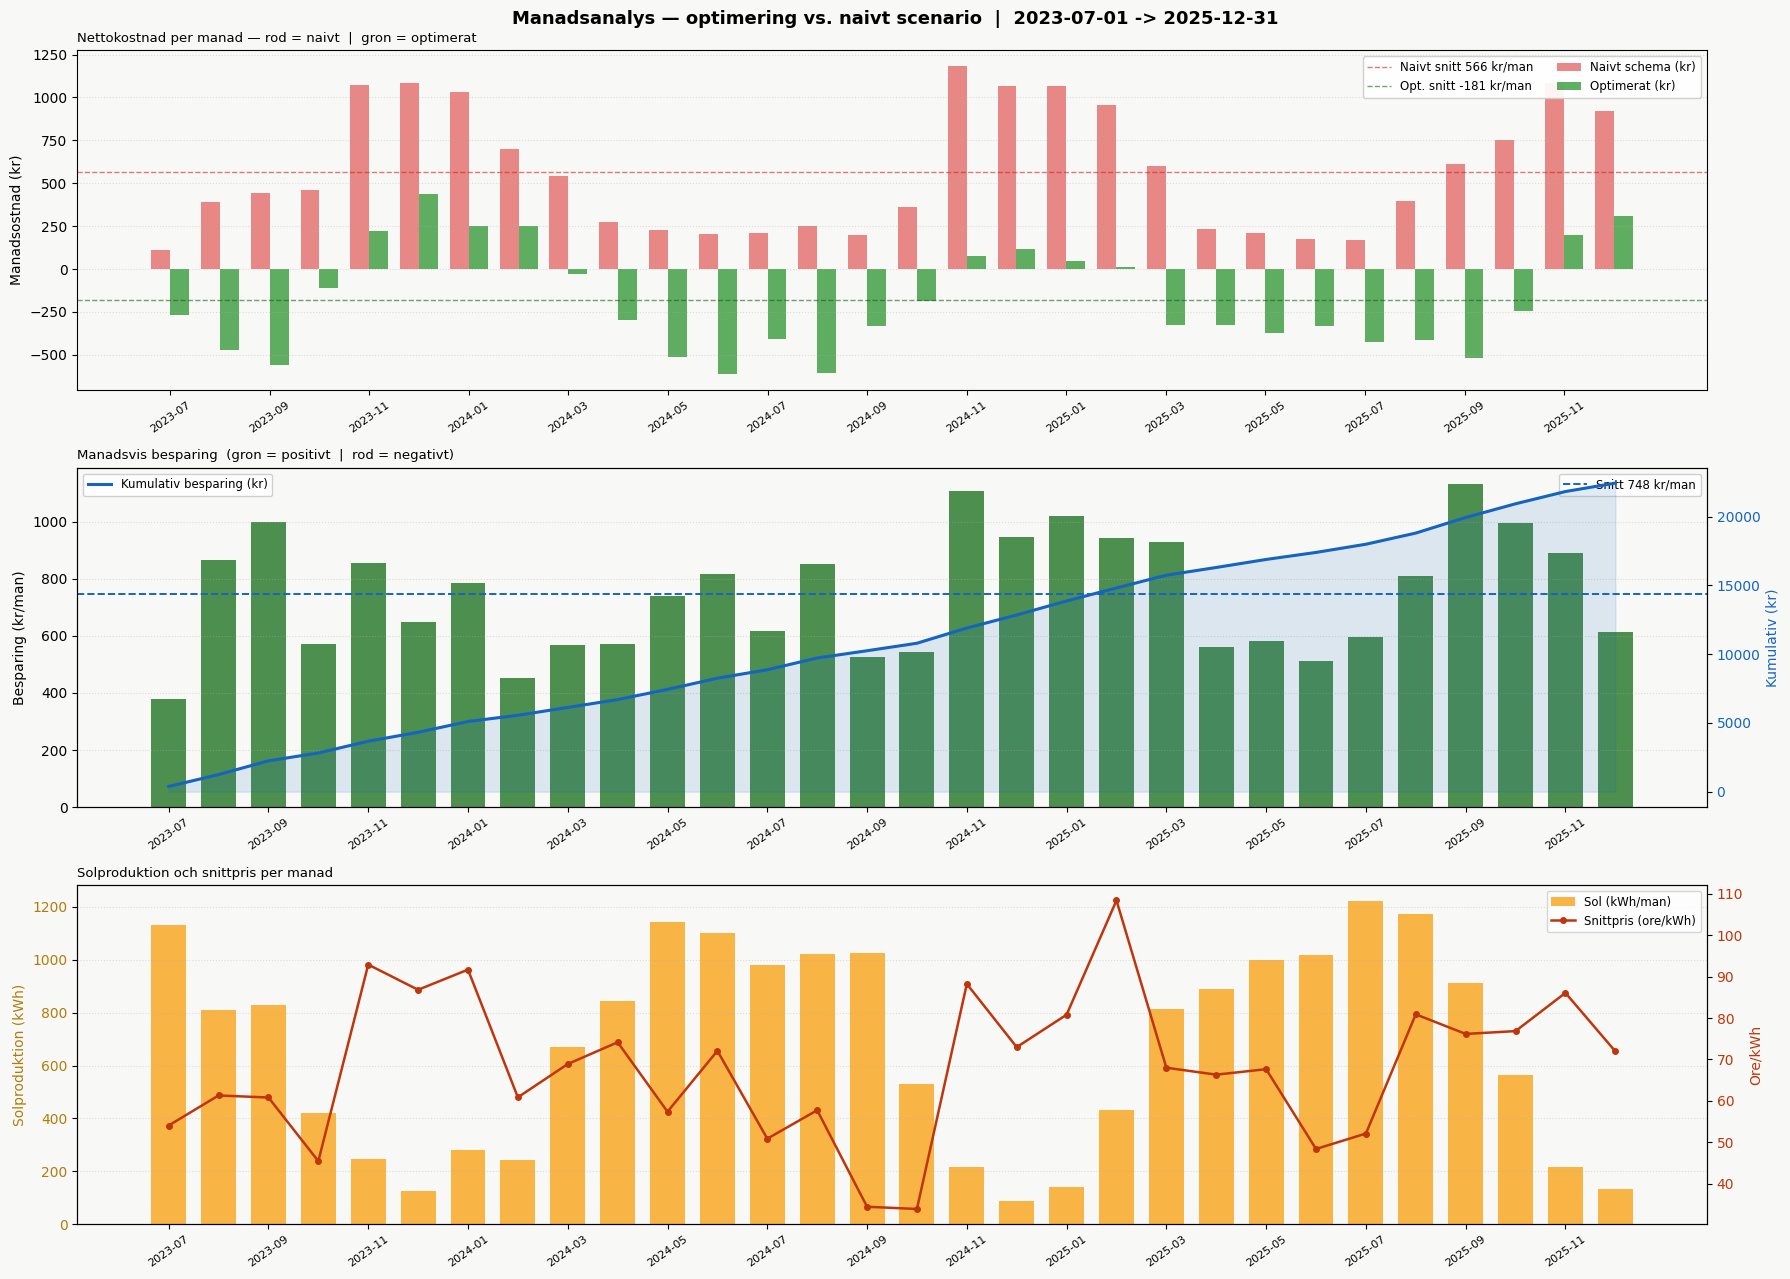

Sparad: manadsbesparing.png


In [160]:
# ══════════════════════════════════════════════════════════════════════════════
# Månadsanalys 2023-07 → 2025-12 — faktisk besparing med optimering
# ══════════════════════════════════════════════════════════════════════════════

import calendar

PERIOD_START = pd.Timestamp('2023-07-01').date()
PERIOD_END   = pd.Timestamp('2025-12-31').date()

period_dates = sorted(set(
    d for d in df_master.index.date
    if PERIOD_START <= d <= PERIOD_END
))
print(f"Period: {period_dates[0]} -> {period_dates[-1]}  ({len(period_dates)} dagar)")
print("Kör optimering per dag...", end='', flush=True)

# ── Kör backtest för hela perioden ────────────────────────────────────────────
monthly_results = []
daily_rows      = []

for day in period_dates:
    day_data = df_master[df_master.index.date == day]
    if len(day_data) < 20:
        continue

    sol_arr = np.array([
        day_data.loc[day_data.index.hour == h, 'total_production_kwh'].sum()
        for h in range(24)
    ])
    price_arr = np.array([
        day_data.loc[day_data.index.hour == h, 'price_total_ore'].mean()
        if h in day_data.index.hour else np.nan
        for h in range(24)
    ])
    if np.isnan(price_arr).any():
        continue

    out = run_optimizer(sol_arr, price_arr)
    if out is None:
        continue

    o_cost, n_cost, o_imp, n_imp = out
    daily_rows.append({
        'datum':         day,
        'ar':            day.year,
        'manad':         day.month,
        'ar_manad':      f"{day.year}-{day.month:02d}",
        'sol_kwh':       sol_arr.sum(),
        'snittpris_ore': price_arr.mean(),
        'naive_kr':      n_cost,
        'opt_kr':        o_cost,
        'besparing_kr':  n_cost - o_cost,
        'naive_imp_kwh': n_imp,
        'opt_imp_kwh':   o_imp,
    })
    print('.', end='', flush=True)

print(f" klar! ({len(daily_rows)} dagar)")

df_daily = pd.DataFrame(daily_rows)

# ── Aggregera per månad ────────────────────────────────────────────────────────
df_monthly = (df_daily
    .groupby('ar_manad')
    .agg(
        antal_dagar    = ('datum',         'count'),
        sol_kwh        = ('sol_kwh',       'sum'),
        snittpris_ore  = ('snittpris_ore', 'mean'),
        naive_kr       = ('naive_kr',      'sum'),
        opt_kr         = ('opt_kr',        'sum'),
        besparing_kr   = ('besparing_kr',  'sum'),
        naive_imp_kwh  = ('naive_imp_kwh', 'sum'),
        opt_imp_kwh    = ('opt_imp_kwh',   'sum'),
    )
    .reset_index()
)
df_monthly['besparing_pct'] = (
    df_monthly['besparing_kr'] / df_monthly['naive_kr'].replace(0, np.nan) * 100
).fillna(0)
df_monthly['kumulativ_kr'] = df_monthly['besparing_kr'].cumsum()

# ── Spara ─────────────────────────────────────────────────────────────────────
df_monthly.to_csv(f'{OUTPUT_DIR}/manadsbesparing.csv', index=False, encoding='utf-8-sig')
df_daily.to_csv(  f'{OUTPUT_DIR}/daglig_besparing_full.csv', index=False, encoding='utf-8-sig')
print(f"\nSparade: manadsbesparing.csv ({len(df_monthly)} manader)  |  "
      f"daglig_besparing_full.csv ({len(df_daily)} dagar)")

# ── Sammanfattning ────────────────────────────────────────────────────────────
total_kr   = df_monthly['besparing_kr'].sum()
avg_mo_kr  = df_monthly['besparing_kr'].mean()
best_mo    = df_monthly.loc[df_monthly['besparing_kr'].idxmax(), 'ar_manad']
best_mo_kr = df_monthly['besparing_kr'].max()
worst_mo   = df_monthly.loc[df_monthly['besparing_kr'].idxmin(), 'ar_manad']
worst_mo_kr= df_monthly['besparing_kr'].min()

print(f"\n{'═'*58}")
print(f"  MANADSANALYS  {PERIOD_START} -> {PERIOD_END}")
print(f"{'═'*58}")
print(f"  {'Manad':<10} {'Dagar':>5}  {'Sol kWh':>8}  "
      f"{'Naivt kr':>9}  {'Opt kr':>8}  {'Spar kr':>8}  {'Spar %':>7}")
print(f"  {'─'*10}  {'─'*5}  {'─'*8}  {'─'*9}  {'─'*8}  {'─'*8}  {'─'*7}")
for _, r in df_monthly.iterrows():
    print(f"  {r['ar_manad']:<10} {r['antal_dagar']:>5}  {r['sol_kwh']:>8.0f}  "
          f"{r['naive_kr']:>9.0f}  {r['opt_kr']:>8.0f}  "
          f"{r['besparing_kr']:>8.0f}  {r['besparing_pct']:>6.1f}%")
print(f"{'═'*58}")
print(f"  Total besparing:     {total_kr:>8.0f} kr")
print(f"  Snitt per manad:     {avg_mo_kr:>8.0f} kr")
print(f"  Basta manad:         {best_mo}  (+{best_mo_kr:.0f} kr)")
print(f"  Samsta manad:        {worst_mo}  ({worst_mo_kr:.0f} kr)")
print(f"{'═'*58}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 13), facecolor='#f8f8f6')
fig.suptitle(f'Manadsanalys — optimering vs. naivt scenario  |  '
             f'{PERIOD_START} -> {PERIOD_END}',
             fontsize=13, fontweight='bold')

x   = np.arange(len(df_monthly))
lbl = df_monthly['ar_manad'].tolist()
tick_step = max(1, len(df_monthly) // 12)

# Panel 1 — Naivt vs. optimerat per månad
ax = axes[0]
ax.set_facecolor('#f8f8f6')
w = 0.38
ax.bar(x - w/2, df_monthly['naive_kr'], width=w,
       color='#e57373', alpha=0.85, label='Naivt schema (kr)')
ax.bar(x + w/2, df_monthly['opt_kr'],   width=w,
       color='#43a047', alpha=0.85, label='Optimerat (kr)')
ax.axhline(df_monthly['naive_kr'].mean(), color='#c62828', linewidth=1.0,
           linestyle='--', alpha=0.6,
           label=f'Naivt snitt {df_monthly["naive_kr"].mean():.0f} kr/man')
ax.axhline(df_monthly['opt_kr'].mean(),   color='#1b5e20', linewidth=1.0,
           linestyle='--', alpha=0.6,
           label=f'Opt. snitt {df_monthly["opt_kr"].mean():.0f} kr/man')
ax.set_ylabel('Manadsostnad (kr)')
ax.set_title('Nettokostnad per manad — rod = naivt  |  gron = optimerat',
             fontsize=9.5, loc='left')
ax.legend(fontsize=8.5, framealpha=0.92, ncol=2)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(lbl[::tick_step], rotation=35, fontsize=8)

# Panel 2 — Månadsbesparing (kr) + kumulativ
ax = axes[1]
ax.set_facecolor('#f8f8f6')
bar_colors = ['#2e7d32' if v >= 0 else '#c62828'
              for v in df_monthly['besparing_kr']]
ax.bar(x, df_monthly['besparing_kr'], color=bar_colors, alpha=0.85, width=0.7)
ax.axhline(avg_mo_kr, color='#1565c0', linewidth=1.4, linestyle='--',
           label=f'Snitt {avg_mo_kr:.0f} kr/man')
ax.axhline(0, color='black', linewidth=0.7)
ax.set_ylabel('Besparing (kr/man)')
ax.set_title('Manadsvis besparing  (gron = positivt  |  rod = negativt)',
             fontsize=9.5, loc='left')
ax.legend(fontsize=8.5, framealpha=0.92)
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax2k = ax.twinx()
ax2k.plot(x, df_monthly['kumulativ_kr'], color='#1565c0',
          linewidth=2.2, label='Kumulativ besparing (kr)')
ax2k.fill_between(x, df_monthly['kumulativ_kr'], alpha=0.12, color='#1565c0')
ax2k.set_ylabel('Kumulativ (kr)', color='#1565c0')
ax2k.tick_params(axis='y', labelcolor='#1565c0')
ax2k.legend(loc='upper left', fontsize=8.5, framealpha=0.92)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(lbl[::tick_step], rotation=35, fontsize=8)

# Panel 3 — Solproduktion per månad
ax = axes[2]
ax.set_facecolor('#f8f8f6')
ax.bar(x, df_monthly['sol_kwh'], color='#f9a825', alpha=0.85, width=0.7,
       label='Sol (kWh/man)')
ax.set_ylabel('Solproduktion (kWh)', color='#b07d0c')
ax.tick_params(axis='y', labelcolor='#b07d0c')
ax3b = ax.twinx()
ax3b.plot(x, df_monthly['snittpris_ore'], color='#bf360c',
          linewidth=1.8, marker='o', markersize=4,
          label='Snittpris (ore/kWh)')
ax3b.set_ylabel('Ore/kWh', color='#bf360c')
ax3b.tick_params(axis='y', labelcolor='#bf360c')
ax.set_title('Solproduktion och snittpris per manad',
             fontsize=9.5, loc='left')
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(lbl[::tick_step], rotation=35, fontsize=8)
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax3b.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, loc='upper right', fontsize=8.5)
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('manadsbesparing.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Sparad: manadsbesparing.png")